## **Data Gathering**

In [2]:
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

In [3]:
#load the HTML content from a local file
with open('smartprix.html', 'r', encoding='utf-8') as file:
    html_content = file.read()

In [4]:
#parse the HTML content using BeautifulSoup
soup = BeautifulSoup(html_content, "html.parser")
#find all product containers
print(soup.prettify())


<html class="way-item-finder sm-smc-in" lang="en" style="--window-width: 1036;">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width" name="viewport"/>
  <title>
   Mobile Phones In Stock | Smartprix
  </title>
  <link href="/sm-32x32.png" rel="icon" sizes="32x32" type="image/png"/>
  <link href="/apple-touch-icon.png" rel="apple-touch-icon" sizes="180x180"/>
  <meta content="#0a3a75" name="theme-color"/>
  <link href="/manifest.json" rel="manifest"/>
  <meta content="app-id=1142915507" name="apple-itunes-app"/>
  <meta content="171761809591603" property="fb:app_id"/>
  <link href="https://www.smartprix.com/mobiles/exclude_out_of_stock-exclude_upcoming-stock" rel="canonical"/>
  <meta content="en_IN" property="og:locale"/>
  <meta content="Smartprix" property="og:site_name"/>
  <meta content="@smartprix" name="twitter:site"/>
  <meta content="@smartprix" name="twitter:creator"/>
  <meta content="summary" name="twitter:card"/>
  <link href="/smartprix_search.xml" rel="

In [5]:
#extract data from each product container
continours = soup.find_all('div', {"class":'sm-product has-tag has-features has-actions'})
#lists to store extracted data
mobile_name = []
mobile_price = []
rank =[]
sim = []
processor = []
ram = []
battery = []
display = []
camera = []
card = []
os = []

#loop through each product container and extract data
for continour in continours:

    '''extract mobile name, price, rank, and specifications, handling missing data with try-except blocks by appending np.nan'''
    try:
        mobile_name.append(continour.find('h2').text)
    except:
        mobile_name.append(np.nan)
    try:
        mobile_price.append(continour.find('span',{"class": "price"}).text)
    except:
        mobile_price.append(np.nan)
    try:
        rank.append(continour.find('div', {'class':'score rank-1-bg' }).find('b').text)
    except:
        rank.append(np.nan)

#extract specifications
    x = continour.find("ul", {"class": "sm-feat specs"}).find_all('li')
    try:
        sim.append(x[0].text)
    except:
        sim.append(np.nan)
    try:
        processor.append(x[1].text)
    except:
        processor.append(np.nan)
    try:
        ram.append(x[2].text)
    except:
        ram.append(np.nan)
    try:
        battery.append(x[3].text)
    except:
        battery.append(np.nan)
    try:
        display.append(x[4].text)
    except:
        display.append(np.nan)
    try:
        camera.append(x[5].text)
    except:
        camera.append(np.nan)
    try:
        card.append(x[6].text)
    except:
        card.append(np.nan)
    try:
        os.append(x[7].text)
    except:
        os.append(np.nan)


In [6]:
os

['Android v14',
 'Android v15',
 'iOS v17',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'Android v14',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v14',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v14',
 'No FM Radio',
 'No FM Radio',
 'No FM Radio',
 'iOS v18',
 'No FM Radio',
 'Android v15',
 'Android v14',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'Android v15',
 'Android v14',
 'Android v14',
 'Android v15',
 'iOS v26',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v15',
 'Android v14',
 'Android v14',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v14',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'Android v16',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'An

In [7]:
#Create a DataFrame from the extracted data
df  = pd.DataFrame({
    "mobile_name" : mobile_name,
    "mobile_price" : mobile_price,
    "mobile_rank" : rank,
    "sim" : sim,
    "processor" : processor,
    "ram" : ram,
    "battery" : battery,
    "display" : display,
    "camera" : camera,
    "card" : card,
    "os" : os
})

#save as spreadsheet for manual data assessing
df.to_excel('smartpix_mobile_data.xlsx', index=False)

df.shape


(1014, 11)

In [8]:
df.head()

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
0,Samsung Galaxy S24 Ultra,"₹79,999",92,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14
1,OnePlus Nord CE 5 5G,"₹23,999",83,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
2,Apple iPhone 15,"₹49,999",81,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A16, Hexa Core, 3.46 GHz Processor","6 GB RAM, 128 GB inbuilt",3349 mAh Battery with Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v17
3,Vivo V60e,"₹29,999",85,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",200 MP + 8 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported,Android v15
4,Realme P3 Ultra (8GB RAM + 256GB),"₹19,999",81,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v15


## **Data cleaning**

### **Data Assessing**
#### **Quality Issues**
1. model - some brands are written diiferently like OPPO in model column "consistency"
2. price - has unneccesary "validity"
3. price has - , between numbers "validity"
4. ratings - missing values "completeness"
5. processor - has some incorrect values "validity"
6. memory - incorrect values "validity"
7. battery - incorrect values "validity"
8. display - incorrect values "validity"
10. camera - problem "validity"
11. card - sometimes contains info about os or camera "validity"
12. os - sometimes contains info about bluetooth and fm radio   "completeness"
13. os - issue with rows "validity"
14.  missing values in mobile_rank(444), camera(2), card(9) and os(20) "completeness"
15. have 8 duplicate rows in the dataset "consistency"

#### **Tidiness Issues**

1. sim - can be split into 3 cols has_5g, has_NFC, has_IR_Blaster
2. ram - can be split into 2 cols RAM and ROM
3. processor - can be split into processor name, cores and cpu speed.
4. battery - can be split into battery capacity, fast_charging_available
5. display - can be split into size, resolution_width, resolution_height and frequency
6. camera - can be split into front and rear camera
7. card - can be split into supported, extended_upto

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   mobile_name   1014 non-null   object
 1   mobile_price  1014 non-null   object
 2   mobile_rank   570 non-null    object
 3   sim           1014 non-null   object
 4   processor     1014 non-null   object
 5   ram           1014 non-null   object
 6   battery       1014 non-null   object
 7   display       1014 non-null   object
 8   camera        1012 non-null   object
 9   card          1005 non-null   object
 10  os            994 non-null    object
dtypes: object(11)
memory usage: 87.3+ KB


In [10]:
df.isnull().sum()

mobile_name       0
mobile_price      0
mobile_rank     444
sim               0
processor         0
ram               0
battery           0
display           0
camera            2
card              9
os               20
dtype: int64

Based on above output we find that we have missing values in mobile_rank(444), camera(2), card(9) and os(20)
also price and rating data type is incorrect

In [11]:
#detect the duplicates from the dataset
print(df.duplicated().sum())
df[df.duplicated()] 

8


,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
497,Realme 14T 5G,"₹15,999",80,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 6300, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 2 TB",Android v15
498,Samsung Galaxy A16 5G (6GB RAM + 128GB),"₹14,078",NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 6300, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2340 px, 90 Hz Display with...",50 MP + 5 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card (Hybrid), upto 1.5 TB",Android v14
537,Nothing Phone 2a Plus (12GB RAM + 256GB),"₹23,999",85,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7350 Pro 5G, Octa Core, 3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 50W Fast Charging,"6.7 inches, 1084 x 2412 px, 120 Hz Display wit...",50 MP + 50 MP Dual Rear & 50 MP Front Camera,Android v14,No FM Radio
677,Motorola Moto G84 5G,"₹18,999",83,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 695, Octa Core, 2.2 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 30W Fast Charging,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card (Hybrid),Android v13
715,Alcatel V3 Ultra (8GB RAM + 128GB),"₹16,999",85,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 6300, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",5010 mAh Battery with 33W Fast Charging,"6.78 inches, 1080 x 2460 px, 120 Hz Display wi...",108 MP + 8 MP + 2 MP Triple Rear & 32 MP Front...,"Memory Card Supported, upto 2 TB",Android v14
716,Alcatel V3 Pro,"₹13,999",80,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 6300, Octa Core, 2.4 GHz Processor","8 GB RAM, 256 GB inbuilt",5200 mAh Battery with 18W Fast Charging,"6.67 inches, 720 x 1600 px, 120 Hz Display wit...",50 MP + 5 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 2 TB",Android v15
935,Samsung Galaxy Z Fold 5 (12GB RAM + 512GB),"₹96,689",91,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 2, Octa Core, 3.36 GHz Processor","12 GB RAM, 512 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1812 x 2176 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v13
994,OPPO F19s,"₹16,999",NaN,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi","Snapdragon 662 , Octa Core, 2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 33W Fast Charging,"6.43 inches, 1080 x 2400 px Display with Punch...",48 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card Supported, upto 256 GB",Android v11


we have 8 duplicate rows in the dataset

In [12]:
df1 = df.copy()

## **start with validity issue**

In [13]:
df1['mobile_price'] = df1["mobile_price"].str.replace('₹','').str.replace(',','').astype(int)
df1['mobile_rank'] = df1['mobile_rank'].astype("float")

In [14]:
df1[df1['mobile_price'] < 3400]['mobile_name']

367             Jio Bharat J1 4G
405           Motorola Moto A300
433      Nokia 105 Dual Sim 2023
456            HMD 105 4G (2024)
483       itel Super Guru 4G Max
500             Jio Bharat V4 4G
502      Jio JioPhone Prima 2 4G
525                  iKall I7 4G
530               Lava Action 4G
572                  iKall I4 4G
577           Motorola Moto A200
586            HMD 110 4G (2024)
633               Foneme F24 Pro
634         HMD 150 Music (2025)
652          Nokia 220 4G (2024)
671       Nokia 105 Classic 2023
720                    MTR Power
726                   Amaq Q1 4G
741                Jio Bharat B2
760           Micromax X1i Smart
771              Snexian Bold 4G
775         Nokia 130 Music 2023
779        Jio Bharat K1 Karbonn
781                Jio Bharat V2
784                 Nokia 106 4G
814            Motorola Moto A70
833               Philips E2101C
835                Karbonn K103i
836                Peace Pura 20
837       Snexian Rock Power Pro
838       

In [15]:
# filter the dataframe  by analysing the data manually below mobile price 3400  then is no any smartphone available with valid entries
df1[df1['mobile_price'] < 3400]
# hence we can remove all the rows below 3400 as they are invalid entries for smartphone analysis
df1 = df1[df1['mobile_price'] >= 3400].reset_index(drop=True)
df1.shape

(964, 11)

In [16]:
#filter the procesor column to extract the wrong data entries which were not having the word 'Processor' in the string and also Unisoc and Tensor processors which are valid processors 
wrong_enitity_processor = df1[~df1['processor'].str.contains('Processor', na=False) & ~df1['processor'].str.contains('Unisoc', na=False) & ~df1['processor'].str.contains('Tensor', na=False)]
wrong_enitity_processor

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [17]:
# filter the wrong entries from ram column using 'RAM' and 'GB' as a filter
wrong_enitity_ram = df1[~df1['ram'].str.contains('GB', na=False) & ~df1['ram'].str.contains('RAM', na=False)]
wrong_enitity_ram

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [18]:
# filter the wrong entries from battery column using ''battery' as a filter
wrong_enitity_battery = df1[~df1['battery'].str.contains('Battery', na=False)]
wrong_enitity_battery

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14,No FM Radio
802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0,No FM Radio
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [19]:
#filtering display column for wrong entries using 'Display' as a filter
wrong_enitity_display = df1[~df1['display'].str.contains('Display', na=False)]
wrong_enitity_display

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14,No FM Radio
802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0,No FM Radio
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [20]:
# filter the camera column for wrong entries using 'Camera' as a filter
wrong_enitity_camera = df1[~df1['camera'].str.contains('Camera', na=False)]
wrong_enitity_camera

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
165,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),216999,97.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","16 GB RAM, 1 TB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
249,Samsung Galaxy Z Fold 7,174999,95.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
260,Motorola Razr 60 5G,44999,89.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7400X, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",4500 mAh Battery with 30W Fast Charging,"6.9 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 13 MP Dual Rear & 32 MP Front Camera,Memory Card Not Supported
372,Lava Agni 3 5G,16999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7300X, Octa Core, 2.5 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 66W Fast Charging,"6.78 inches, 1200 x 2652 px, 120 Hz Display wi...",Dual Display,50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front ...,Memory Card Not Supported
376,Samsung Galaxy Z Flip 4 (8GB RAM + 256GB),41370,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","8 GB RAM, 256 GB inbuilt",3700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
396,Vivo X Fold 3 Pro,159999,96.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","16 GB RAM, 512 GB inbuilt",5700 mAh Battery with 100W Fast Charging,"8.03 inches, 2200 x 2480 px, 120 Hz Display wi...","Foldable Display, Dual Display",64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32...,Memory Card Not Supported
397,Samsung Galaxy Z Fold 6,109999,90.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 3, Octa Core, 3.39 GHz Processor","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1856 x 2160 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v14
416,Motorola Razr 60 Ultra,79999,93.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8 Elite, Octa Core, 4.32 GHz Processor","16 GB RAM, 512 GB inbuilt",4700 mAh Battery with 68W Fast Charging,"6.96 inches, 1224 x 2992 px, 165 Hz Display wi...","Foldable Display, Dual Display",50 MP + 50 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported


In [21]:
# filter the memory card column for wrong entries using 'Memory' as a filter
wrong_enitity_card = df1[~df1['card'].str.contains('Memory', na=False)]
wrong_enitity_card

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
11,Vivo T4 Pro 5G,27499,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, IR B...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Android v15,No FM Radio
12,Motorola Edge 60 Pro,27475,80.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Dimensity 8350 Extreme, Octa Core, 3.35 GHz Pr...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 90W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 50 MP + 10 MP Triple Rear & 50 MP Fron...,Android v15,No FM Radio
15,Poco X7 5G,14999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC,...","Dimensity 7300 Ultra, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",5500 mAh Battery with 45W Fast Charging,"6.67 inches, 1220 x 2712 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v14,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...
953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
955,Microsoft Surface Duo 2,79990,85.0,"Single Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",4449 mAh Battery with 23W Fast Charging,"8.3 inches, 1892 x 2688 px, 90 Hz Display","Foldable Display, Dual Display",16 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Android v11
957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


In [22]:
df1['os'].unique()

array(['Android v14', 'Android v15', 'iOS v17', 'No FM Radio', 'iOS v18',
       'iOS v26', 'Android v16', 'Bluetooth', 'iOS v15', 'iOS v16',
       'RTOS Touch', 'Android v11', 'Android v13',
       'Memory Card Not Supported', 'Android v12', 'Android v10.0',
       'Android v10', '0.3 MP Rear Camera', 'Android v9.0 (Pie)',
       'iOS v13', 'Android v10.1', 'Memory Card Supported, upto 32 GB',
       'Memory Card Supported', 'Android v8.1 (Oreo)'], dtype=object)

In [23]:
# filtering os column for wrong entries using 'Android' or 'iOS' or 'RTOS' or 'Symbian', or 'Nucleus' or 'S30' as a filter
wrong_enitity_os = df1[~df1['os'].str.contains('Android', na=False) & ~df1['os'].str.contains('iOS', na=False) & ~df1['os'].str.contains('RTOS', na=False) & ~df1['os'].str.contains('Symbian', na=False) & ~df1['os'].str.contains('Nucleus', na=False) & ~df1['os'].str.contains('S30', na=False)]
wrong_enitity_os

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
11,Vivo T4 Pro 5G,27499,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, IR B...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Android v15,No FM Radio
12,Motorola Edge 60 Pro,27475,80.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Dimensity 8350 Extreme, Octa Core, 3.35 GHz Pr...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 90W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 50 MP + 10 MP Triple Rear & 50 MP Fron...,Android v15,No FM Radio
15,Poco X7 5G,14999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC,...","Dimensity 7300 Ultra, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",5500 mAh Battery with 45W Fast Charging,"6.67 inches, 1220 x 2712 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v14,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...
950,Realme GT 2 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 65W Fast Charging,"6.62 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,Android v12,No FM Radio
953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


In [24]:
# combine all the filtered dataframes to get the wrong entries in the dataset without duplicates
wrong_entries = pd.concat([wrong_enitity_processor, wrong_enitity_ram, wrong_enitity_battery, wrong_enitity_display, wrong_enitity_camera, wrong_enitity_card, wrong_enitity_os]).drop_duplicates()
wrong_entries

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...
950,Realme GT 2 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 65W Fast Charging,"6.62 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,Android v12,No FM Radio
953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


#### **Now start the cleaning column by column based on remaining wrong entries found**


In [25]:
df1.reset_index(inplace=True)

In [26]:
#cleaning the processor column
df1[df1['index'].isin(wrong_enitity_processor.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [27]:
# Based on web analysis none of the above reaming phone are smartphones so we can remove them from the dataset
df1.drop(wrong_enitity_processor.index, inplace=True)
#from this primary cleaning for processor column is done 

In [28]:
 # claining the ram column
wrong_enitity_ram

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [29]:
#cleaning the ram column
df1[df1['index'].isin(wrong_enitity_ram.index)]

#There is no wrong entries in the ram column

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os


In [30]:
#cleaning the battery column
df1[df1['index'].isin(wrong_enitity_battery.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
690,690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14,No FM Radio
802,802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0,No FM Radio


In [31]:
# based on the above data we need to right shift from the battery column upto card column meaning the next os column is needs to filed by present card data and present os column data needs to delete and we need to fill na to battery column
temp_df1 = df1[df1['index'].isin(wrong_enitity_battery.index)]
temp_df1
x = temp_df1.iloc[:, 7:].shift(1, axis=1).values

df1.loc[temp_df1.index, temp_df1.columns[7:]] = x

In [32]:

df1[df1['index'].isin(wrong_enitity_battery.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
690,690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14
802,802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0


In [33]:
# next cleaning the display column 
df1[df1['index'].isin(wrong_enitity_display.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
690,690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14
802,802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0


In [34]:
# there is no primary cleaning required in the display column
# now needs to clean the camera column
df1[df1['index'].isin(wrong_enitity_camera.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
165,165,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),216999,97.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","16 GB RAM, 1 TB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
249,249,Samsung Galaxy Z Fold 7,174999,95.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
260,260,Motorola Razr 60 5G,44999,89.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7400X, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",4500 mAh Battery with 30W Fast Charging,"6.9 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 13 MP Dual Rear & 32 MP Front Camera,Memory Card Not Supported
372,372,Lava Agni 3 5G,16999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7300X, Octa Core, 2.5 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 66W Fast Charging,"6.78 inches, 1200 x 2652 px, 120 Hz Display wi...",Dual Display,50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front ...,Memory Card Not Supported
376,376,Samsung Galaxy Z Flip 4 (8GB RAM + 256GB),41370,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","8 GB RAM, 256 GB inbuilt",3700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
396,396,Vivo X Fold 3 Pro,159999,96.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","16 GB RAM, 512 GB inbuilt",5700 mAh Battery with 100W Fast Charging,"8.03 inches, 2200 x 2480 px, 120 Hz Display wi...","Foldable Display, Dual Display",64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32...,Memory Card Not Supported
397,397,Samsung Galaxy Z Fold 6,109999,90.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 3, Octa Core, 3.39 GHz Processor","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1856 x 2160 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v14
416,416,Motorola Razr 60 Ultra,79999,93.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8 Elite, Octa Core, 4.32 GHz Processor","16 GB RAM, 512 GB inbuilt",4700 mAh Battery with 68W Fast Charging,"6.96 inches, 1224 x 2992 px, 165 Hz Display wi...","Foldable Display, Dual Display",50 MP + 50 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported


In [35]:
# by the above data we get that the camera column as only foldable display info it was invalid so we need to convert these info as np.nan
df1.loc[df1['index'].isin(wrong_enitity_camera.index), 'camera'] = np.nan


In [36]:
df1[df1['index'].isin(wrong_enitity_camera.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",NaN,Memory Card Not Supported,iOS v26
165,165,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),216999,97.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","16 GB RAM, 1 TB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...",NaN,200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
249,249,Samsung Galaxy Z Fold 7,174999,95.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...",NaN,200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
260,260,Motorola Razr 60 5G,44999,89.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7400X, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",4500 mAh Battery with 30W Fast Charging,"6.9 inches, 1080 x 2640 px, 120 Hz Display wit...",NaN,50 MP + 13 MP Dual Rear & 32 MP Front Camera,Memory Card Not Supported
372,372,Lava Agni 3 5G,16999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7300X, Octa Core, 2.5 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 66W Fast Charging,"6.78 inches, 1200 x 2652 px, 120 Hz Display wi...",NaN,50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front ...,Memory Card Not Supported
376,376,Samsung Galaxy Z Flip 4 (8GB RAM + 256GB),41370,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","8 GB RAM, 256 GB inbuilt",3700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...",NaN,12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",NaN,Memory Card Not Supported,iOS v26
396,396,Vivo X Fold 3 Pro,159999,96.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","16 GB RAM, 512 GB inbuilt",5700 mAh Battery with 100W Fast Charging,"8.03 inches, 2200 x 2480 px, 120 Hz Display wi...",NaN,64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32...,Memory Card Not Supported
397,397,Samsung Galaxy Z Fold 6,109999,90.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 3, Octa Core, 3.39 GHz Processor","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1856 x 2160 px, 120 Hz Display wit...",NaN,50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v14
416,416,Motorola Razr 60 Ultra,79999,93.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8 Elite, Octa Core, 4.32 GHz Processor","16 GB RAM, 512 GB inbuilt",4700 mAh Battery with 68W Fast Charging,"6.96 inches, 1224 x 2992 px, 165 Hz Display wi...",NaN,50 MP + 50 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported


In [37]:
 # now we need to clean the memory card column
df1[df1['index'].isin(wrong_enitity_card.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
5,5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
7,7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
11,11,Vivo T4 Pro 5G,27499,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, IR B...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Android v15,No FM Radio
12,12,Motorola Edge 60 Pro,27475,80.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Dimensity 8350 Extreme, Octa Core, 3.35 GHz Pr...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 90W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 50 MP + 10 MP Triple Rear & 50 MP Fron...,Android v15,No FM Radio
15,15,Poco X7 5G,14999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC,...","Dimensity 7300 Ultra, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",5500 mAh Battery with 45W Fast Charging,"6.67 inches, 1220 x 2712 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v14,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...,...
953,953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
955,955,Microsoft Surface Duo 2,79990,85.0,"Single Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",4449 mAh Battery with 23W Fast Charging,"8.3 inches, 1892 x 2688 px, 90 Hz Display",NaN,16 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Android v11
957,957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


In [38]:
# viewing of complete value counts of the card column which are there in df1 with index matcjing with wrong_enitity_card in the card column using pandas max row option 

df1[df1['index'].isin(wrong_enitity_card.index)]['card'].value_counts()

card
Android v15                                                                126
Android v14                                                                 73
Android v12                                                                 30
Android v13                                                                 27
Android v11                                                                  7
50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 MP Dual Front Camera           7
Memory Card Not Supported                                                    4
50 MP + 12 MP Dual Rear & 10 MP Front Camera                                 4
50 MP + 13 MP Dual Rear & 32 MP Front Camera                                 3
Android v16                                                                  3
200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 10 MP Dual Front Camera         3
12 MP + 12 MP Dual Rear & 10 MP Front Camera                                 3
Android v10                                    

In [39]:
df1.head(20)

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
0,0,Samsung Galaxy S24 Ultra,79999,92.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14
1,1,OnePlus Nord CE 5 5G,23999,83.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
2,2,Apple iPhone 15,49999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A16, Hexa Core, 3.46 GHz Processor","6 GB RAM, 128 GB inbuilt",3349 mAh Battery with Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v17
3,3,Vivo V60e,29999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",200 MP + 8 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported,Android v15
4,4,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v15
5,5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
6,6,Motorola Edge 60 Fusion,20829,84.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7400, Octa Core, 2.5 GHz Processor","8 GB RAM, 256 GB inbuilt",5500 mAh Battery with 68W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 13 MP Dual Rear & 32 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
7,7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
8,8,Vivo T4x 5G,13499,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 7300, Octa Core, 2.5 GHz Processor","6 GB RAM, 128 GB inbuilt",6500 mAh Battery with 44W Fast Charging,"6.72 inches, 1080 x 2408 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Not Supported,Android v15
9,9,Samsung Galaxy S24 FE 5G,34790,84.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Exynos 2400e, Deca Core, 3.11 GHz Processor","8 GB RAM, 128 GB inbuilt",4700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 8 MP Triple Rear & 10 MP Front...,Memory Card Not Supported,Android v14


In [40]:
# based on the above value counts we have more then 200 anroid data is there in the card column has we need to shift the card column which cantain anroid name with any varients (Android v15 , Android v14 etc) if this  data is there in card column we need to shift that card cell to os cell to the same index and the that shifted cell of the card fill with na
# hence we can do the right shift for the card column only for the rows which contain android in the card column and that shifted cell of the card fill with na
# hence we just need to do shift the card column having andriod name to the same index in os column and fill np.nan in the card column to the particuler index
# temp_df3 = df1[df1['card'].str.contains('Android', na=False)]
# x3 = temp_df3.iloc[:, 10:].shift(1, axis=1).values
# df1.loc[temp_df3.index, temp_df3.columns[10:]] = x3
# df1[df1['index'].isin(wrong_enitity_card.index)] = df1[df1['index'].isin(wrong_enitity_card.index)].fillna(np.nan)

df1.loc[df1['card'].str.contains('Android', na=False), 'os'] = df1.loc[df1['card'].str.contains('Android', na=False), 'card']
df1.loc[df1['card'].str.contains('Android', na=False), 'card'] = np.nan


In [41]:
df1[df1['index'].isin(wrong_enitity_card.index)]['card'].value_counts()

card
50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 MP Dual Front Camera         7
Memory Card Not Supported                                                  4
50 MP + 12 MP Dual Rear & 10 MP Front Camera                               4
12 MP + 12 MP Dual Rear & 10 MP Front Camera                               3
200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 10 MP Dual Front Camera       3
50 MP + 13 MP Dual Rear & 32 MP Front Camera                               3
50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front Camera                       2
48 MP + 10.8 MP + 10.5 MP Triple Rear & 10 MP + 10 MP Dual Front Camera    2
50 MP + 50 MP Dual Rear & 50 MP Front Camera                               2
64 MP + 2 MP Dual Rear & 16 MP Front Camera                                2
50 MP + 50 MP Dual Rear & 32 MP Front Camera                               2
64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32 MP Dual Front Camera        1
50 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32 MP Dual Front Camera    

In [42]:
# in a same way we have more then 30 camera information in the card column hence  if the data in the card cell having 'MP' name we need to shift that particuler column to left meaning cemara column and needs to fill that cells in the card column as np.nan other then this don't do any other operation which affects the other column 
df1.loc[df1['card'].str.contains('MP', na=False), 'camera'] = df1.loc[df1['card'].str.contains('MP', na=False), 'card']
df1.loc[df1['card'].str.contains('MP', na=False), 'card'] = np.nan

In [43]:
df1[df1['index'].isin(wrong_enitity_card.index)]['card'].value_counts()

card
Memory Card Not Supported    4
Name: count, dtype: int64

In [44]:
# need to clean the os column
df1[df1['index'].isin(wrong_enitity_os.index)]['os'].value_counts()

os
Android v15                  126
Android v14                   73
Android v12                   30
Android v13                   27
Memory Card Not Supported     22
Android v11                    7
Android v16                    3
Android v10                    2
iOS v26                        2
Android                        1
iOS v14                        1
iOS v14.0                      1
Android v12.0                  1
Name: count, dtype: int64

In [45]:
# based on the above value counts we have some Memory Card Not Supported info in the os column hence if the data in the card cell having 'Memory' name we need to shift that particuler column to left meaning card column and needs to fill that cells in the os column as np.nan other then this don't do any other operation which affects the other column
df1.loc[df1['os'].str.contains('Memory', na=False), 'card'] = df1.loc[df1['os'].str.contains('Memory', na=False), 'os']
df1.loc[df1['os'].str.contains('Memory', na=False), 'os'] = np.nan

In [46]:
# need to clean the os column
df1[df1['index'].isin(wrong_enitity_os.index)]['os'].value_counts()

os
Android v15      126
Android v14       73
Android v12       30
Android v13       27
Android v11        7
Android v16        3
iOS v26            2
Android v10        2
Android            1
iOS v14            1
iOS v14.0          1
Android v12.0      1
Name: count, dtype: int64

In [47]:
df1.isnull().sum()

index             0
mobile_name       0
mobile_price      0
mobile_rank     390
sim               0
processor         0
ram               0
battery           4
display           0
camera            4
card            284
os               22
dtype: int64

In [48]:
df1['processor'].value_counts()

processor
Dimensity 6300, Octa Core, 2.4 GHz Processor         106
Snapdragon 4 Gen2, Octa Core, 2.2 GHz Processor       24
Dimensity 7300, Octa Core, 2.5 GHz Processor          23
Snapdragon 7 Gen3, Octa Core, 2.63 GHz Processor      21
Dimensity 6100 Plus, Octa Core, 2.2 GHz Processor     19
                                                    ... 
Snapdragon  720G, Octa Core, 2.3 GHz Processor         1
Dimensity 1000+, Octa Core, 2.6 GHz Processor          1
Snapdragon 765G , Octa Core, 2.4 GHz Processor         1
Helio G85 , Octa Core, 2 GHz Processor                 1
Snapdragon 460, Octa Core, 1.8 GHz Processor           1
Name: count, Length: 224, dtype: int64

In [49]:
df1['ram'].value_counts()

ram
8 GB RAM, 128 GB inbuilt     242
8 GB RAM, 256 GB inbuilt     191
6 GB RAM, 128 GB inbuilt     127
12 GB RAM, 256 GB inbuilt    119
4 GB RAM, 128 GB inbuilt      72
4 GB RAM, 64 GB inbuilt       69
12 GB RAM, 512 GB inbuilt     49
16 GB RAM, 512 GB inbuilt     20
8 GB RAM, 512 GB inbuilt      11
16 GB RAM, 256 GB inbuilt     10
3 GB RAM, 64 GB inbuilt        7
3 GB RAM, 32 GB inbuilt        5
6 GB RAM, 64 GB inbuilt        5
12 GB RAM, 1 TB inbuilt        5
12 GB RAM, 128 GB inbuilt      4
8 GB RAM, 1 TB inbuilt         4
6 GB RAM, 256 GB inbuilt       3
2 GB RAM, 32 GB inbuilt        2
16 GB RAM, 1 TB inbuilt        2
32 GB RAM, 3 GB inbuilt        1
128 GB inbuilt                 1
128 MB RAM, 64 MB inbuilt      1
24 GB RAM, 1 TB inbuilt        1
12 GB RAM, 2 TB inbuilt        1
3 GB RAM, 16 GB inbuilt        1
256 GB inbuilt                 1
6 GB RAM, 512 GB inbuilt       1
2 GB RAM, 64 GB inbuilt        1
1 GB RAM, 8 GB inbuilt         1
512 GB inbuilt                 1
4 GB R

In [50]:
df1['battery'].value_counts()

battery
5000 mAh Battery with 18W Fast Charging     60
5000 mAh Battery with 33W Fast Charging     60
5000 mAh Battery with 25W Fast Charging     57
5000 mAh Battery with 45W Fast Charging     50
6000 mAh Battery with 45W Fast Charging     33
                                            ..
5000 mAh Battery with 65W Fast Charging      1
4449 mAh Battery with 23W Fast Charging      1
4350 mAh Battery with 120W Fast Charging     1
4350 mAh Battery with 65W Fast Charging      1
4000 mAh Battery with 33W Fast Charging      1
Name: count, Length: 186, dtype: int64

In [51]:
df1['display'].value_counts()

display
6.67 inches, 1080 x 2400 px, 120 Hz Display with Punch Hole       76
6.77 inches, 1080 x 2392 px, 120 Hz Display with Punch Hole       49
6.7 inches, 1080 x 2412 px, 120 Hz Display with Punch Hole        44
6.67 inches, 720 x 1604 px, 120 Hz Display with Punch Hole        29
6.67 inches, 1220 x 2712 px, 120 Hz Display with Punch Hole       20
                                                                  ..
6.7 inches, 1080 x 2460 px, 144 Hz Display with Punch Hole         1
8.3 inches, 1892 x 2688 px, 90 Hz Display                          1
6.53 inches, 1080 x 2400 px, 90 Hz Display with Punch Hole         1
6.5 inches, 720 x 1600 px, 90 Hz Display with Water Drop Notch     1
6.44 inches, 1080 x 2400 px Display with Small Notch               1
Name: count, Length: 217, dtype: int64

In [52]:
df1['camera'].value_counts()

camera
50 MP + 2 MP Dual Rear & 8 MP Front Camera                          72
50 MP + 2 MP Dual Rear & 16 MP Front Camera                         54
50 MP + 8 MP Dual Rear & 16 MP Front Camera                         31
50 MP + 2 MP Dual Rear & 32 MP Front Camera                         25
50 MP + 5 MP + 2 MP Triple Rear & 13 MP Front Camera                24
                                                                    ..
64 MP + 13 MP + 5 MP Triple Rear & 24 MP Front Camera                1
16 MP + 12 MP + 12 MP Triple Rear & 12 MP Front Camera               1
48 MP + 13 MP + 13 MP Triple Rear & 16 MP Front Camera               1
64 MP + 8 MP + 2 MP Triple Rear & 44 MP + 8 MP Dual Front Camera     1
48 MP + 8 MP + 2 MP Triple Rear & 8 MP Front Camera                  1
Name: count, Length: 198, dtype: int64

In [53]:
df1['card'].value_counts()

card
Memory Card Not Supported             222
Memory Card (Hybrid), upto 1 TB       146
Memory Card Supported, upto 1 TB       99
Memory Card (Hybrid), upto 2 TB        69
Memory Card (Hybrid)                   41
Memory Card Supported                  27
Memory Card Supported, upto 2 TB       24
Memory Card Supported, upto 512 GB     20
Memory Card (Hybrid), upto 1.5 TB      12
Memory Card Supported, upto 256 GB      9
Memory Card (Hybrid), upto 256 GB       4
Memory Card Supported, upto 128 MB      1
Memory Card (Hybrid), upto 128 GB       1
Memory Card Supported, upto 128 GB      1
Name: count, dtype: int64

In [54]:
df1['os'].value_counts()

os
Android v15            326
Android v14            298
Android v13            117
Android v12             73
Android v11             50
iOS v18                 16
iOS v26                 12
Android v16             10
iOS v17                  9
Android v10              7
Android v9.0 (Pie)       5
iOS v16                  3
Android v10.0            2
iOS v15                  2
RTOS Touch               1
Android                  1
iOS v13                  1
Android v10.1            1
iOS v14                  1
iOS v14.0                1
Android v8.1 (Oreo)      1
Android v12.0            1
Name: count, dtype: int64

In [55]:
df1.to_excel('smartpix_mobile_data_cleaned.xlsx', index=False)


## **Resolving tidiness problem**

In [56]:
brand_names = df1['mobile_name'].str.split(' ').str.get(0)
df1.insert(1, 'brand_name', brand_names)

In [57]:
# lower the case of brand_names  
df1['brand_name'] = df1['brand_name'].str.lower()

In [58]:
df1.head()

,index,brand_name,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
0,0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14
1,1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
2,2,apple,Apple iPhone 15,49999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A16, Hexa Core, 3.46 GHz Processor","6 GB RAM, 128 GB inbuilt",3349 mAh Battery with Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v17
3,3,vivo,Vivo V60e,29999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",200 MP + 8 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported,Android v15
4,4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v15


In [59]:
# from sim column we can extract unique and imp info of the mobile mainly 5G or not , NFC include or not, IR blutooth version present or not
has_5g = df1['sim'].str.contains('5G')
has_nfc = df1['sim'].str.contains('NFC')
has_ir = df1['sim'].str.contains('IR')

df1.insert(6, 'has_5g', has_5g)
df1.insert(7, 'has_nfc', has_nfc)
df1.insert(8, 'has_ir', has_ir)

In [60]:
# in processor we have  name of the processor,  brand of the processor, no of core, and speed of the processor
processor_name = df1['processor'].str.split(',').str.get(0)

# but the core deatils in the column as octa hexa etc and also some of the processor cells not having the core deatils if some of them are had not in a similer sequesqnce throwout the column by considering this we needs to extract this info carefully
processor_cores = df1['processor'].str.split(',').str.get(1)

processor_speed = df1['processor'].str.split(',').str.get(2)


df1.insert(10, 'processor_name', processor_name)
df1.insert(11, 'processor_cores', processor_cores)
df1.insert(12, 'processor_speed', processor_speed)

In [61]:
df1['processor_name'] = df1['processor_name'].str.strip()
df1['processor_cores'] = df1['processor_cores'].str.strip()
df1['processor_speed'] = df1['processor_speed'].str.strip()

In [62]:
df1.loc[df1['processor_name'].str.contains('Core', na=False), 'processor_cores'] = df1.loc[df1['processor_name'].str.contains('Core', na=False), 'processor_name']
df1.loc[df1['processor_name'].str.contains('Core', na=False), 'processor_name'] = np.nan

In [63]:
precessor_brand  = df1['processor_name'].str.split().str.get(0).str.lower()
df1.insert(12, 'processor_brand', precessor_brand)

In [64]:
df1['processor_cores'].value_counts()

processor_cores
Octa Core              867
Hexa Core               33
Octa Core Processor     21
Hexa Core Processor     12
Deca Core               10
Single Core              5
Nine-Cores               2
Nine Cores               2
Quad Core                2
Nine Core                1
Name: count, dtype: int64

In [65]:
""" above data are the cores info pressent in the processor_cores column 
now we need to convert info info in numarical columan 
meaning oct core to 8 like that with considering the above info """
core_mapping = {
    'Single Core': 1,
    'Dual Core': 2,
    'Triple Core': 3,
    'Quad Core': 4,
    'Penta Core': 5,
    'Hexa Core': 6,
    'Hepta Core': 7,
    'Octa Core': 8,
    'Nine Core': 9,
    'Nine-Cores': 9,
    'Deca Core': 10
}

df1['processor_cores'] = df1['processor_cores'].str.replace(' Processor', '', regex=False)
df1['processor_cores'] = df1['processor_cores'].map(core_mapping)

In [66]:
df1['processor_cores'] = df1['processor_cores'].astype('Int64')

In [67]:
""" in the same way we have the processer_speed column with these data here
we can observe that we have similer data but with two different units GHz and MHz 
we need to convert all the data into GHz and also need to remove the 'Processor' word from the cells 
to make it clean numeric column with processser speed value in GHz only """
def convert_to_ghz(process_speed):
    if pd.isna(process_speed):
        return np.nan
    process_speed = process_speed.replace(' Processor', '').strip()
    value, unit = process_speed.split()
    value = float(value)
    if unit == 'MHz':
        value = value / 1000  # Convert MHz to GHz
    return value

df1['processor_speed'] = df1['processor_speed'].apply(convert_to_ghz)

In [68]:
# in the same way we can make 2 column from ram column one is ram_size and other is rom(storage size)
ram_storage = df1['ram'].str.strip().str.split(',')
df1['ram_size'] = ram_storage.str[0]
df1['rom_size'] = ram_storage.str[1]

In [69]:
df1['ram_size'].value_counts()

ram_size
8 GB RAM          448
12 GB RAM         178
4 GB RAM          142
6 GB RAM          136
16 GB RAM          32
3 GB RAM           13
2 GB RAM            3
128 MB RAM          1
32 GB RAM           1
24 GB RAM           1
128 GB inbuilt      1
256 GB inbuilt      1
1 GB RAM            1
512 GB inbuilt      1
18 GB RAM           1
Name: count, dtype: int64

In [70]:
""" while observing the ram_size column we can see that some entries are rom information which not having ram in there cell example 128 GB inbuilt etc 
first we need transerfer cells data as it is to rom_size column to the same index and fill np.nan to the ram_size column to the same index
then as we can see above all the ram size are in GB except few entries which are in MB here we need to clean the ram data to one unit GB 
and extract the numaric value then we need to convert the ram_size column to numeric and fill any missing values with np.nan
"""
df1.loc[df1['ram_size'].str.contains('inbuilt', na=False), 'rom_size'] = df1.loc[df1['ram_size'].str.contains('inbuilt', na=False), 'ram_size']
df1.loc[df1['ram_size'].str.contains('inbuilt', na=False), 'ram_size'] = np.nan

def convert_ram_to_gb(ram_size):
    if pd.isna(ram_size):
        return np.nan
    ram_size = ram_size.replace('RAM', '').strip()
    value, unit = ram_size.split()
    value = float(value)
    if unit == 'MB':
        value = value / 1024  # Convert MB to GB
    return value

df1['ram_size'] = df1['ram_size'].apply(convert_ram_to_gb)
df1['ram_size'] = df1['ram_size'].astype('Float64')


In [71]:
df1['ram_size'] = df1['ram_size'].astype('Int64')
df1['ram_size'].value_counts()

ram_size
8     448
12    178
4     142
6     136
16     32
3      13
2       3
32      1
0       1
24      1
1       1
18      1
Name: count, dtype: Int64

In [72]:
df1["rom_size"].value_counts()

rom_size
 128 GB inbuilt    445
 256 GB inbuilt    323
 512 GB inbuilt     83
 64 GB inbuilt      82
 1 TB inbuilt       12
 32 GB inbuilt       7
 3 GB inbuilt        1
 64 MB inbuilt       1
128 GB inbuilt       1
 2 TB inbuilt        1
256 GB inbuilt       1
 16 GB inbuilt       1
 8 GB inbuilt        1
512 GB inbuilt       1
Name: count, dtype: int64

In [73]:
# here we also need to convert TB to GB and if we have MB we need change that to np.nan because in smart phone we dont have storage in MB (less)
def convert_rom_to_gb(rom_size):
    if pd.isna(rom_size):
        return np.nan
    rom_size = rom_size.replace('inbuilt', '').strip()
    value, unit = rom_size.split()
    value = float(value)
    if unit == 'MB':
        return np.nan  # Convert MB to NaN
    elif unit == 'TB':
        value = value * 1024  # Convert TB to GB
    return value
df1['rom_size'] = df1['rom_size'].apply(convert_rom_to_gb)
df1['rom_size'] = df1['rom_size'].astype('Float64')

In [74]:
df1['rom_size'] = df1['rom_size'].astype('Int64')
df1['rom_size'].value_counts()

df1[df1['rom_size'] ==3] # 32 GB RAM, 3 GB inbuilt this shows that these mobiles have 32 GB RAM and 3 GB storage which is not possible based on the web analysis it has 3 GB Ram and 32 GB storage hence we need to swap these values to make it correct
df1.loc[df1['rom_size'] == 3, ['ram_size', 'rom_size']] = df1.loc[df1['rom_size'] == 3, ['rom_size', 'ram_size']].values


In [75]:
"""as the same way we can extract two column from battery column one is battery_capacity, and charger_wattage
here the pattern is we have battery capacity with the number followed by space then mah example 5000 mAh , and wattage with number with W example 33W """
df1['battery_capacity'] = df1['battery'].str.strip().str.split(' ').str.get(0).astype('Int64')

df1['battery'].str.strip().str.split('with').str.get(1)

def extract_charger_wattage(charger_info):
    if pd.isna(charger_info):
        return np.nan
    charger_info = charger_info.strip()
    parts = charger_info.split(' ')
    for part in parts:
        if part.endswith('W'):
            try:
                return int(part.replace('W', ''))
            except ValueError:
                return np.nan
    return np.nan
df1['charger_wattage'] = df1['battery'].str.strip().str.split('with').str.get(1).apply(extract_charger_wattage).astype('Int64')


In [76]:
# in the same way we can extract 3  features from display column one is display_size , display_resolution, Hz of the display
df1['screen_size'] = df1['display'].str.strip().str.split(',').str.get(0).str.strip().str.split(' ').str.get(0).astype('float64')

df1['display_resolution_width'] = df1['display'].str.strip().str.split(',').str.get(1).str.strip().str.split('px').str.get(0).str.strip().str.split(" x ").str.get(0).astype('Int64')
df1['display_resolution_height'] = df1['display'].str.strip().str.split(',').str.get(1).str.strip().str.split('px').str.get(0).str.strip().str.split(" x ").str.get(1).astype('Int64')

df1['display_refresh_rate'] = df1['display'].str.strip().str.split(',').str.get(2).str.strip().str.split(' ').str.get(0).astype('Int64')


In [77]:
df1.head()

,index,brand_name,mobile_name,mobile_price,mobile_rank,sim,has_5g,has_nfc,has_ir,processor,...,card,os,ram_size,rom_size,battery_capacity,charger_wattage,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate
0,0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC",True,True,False,"Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor",...,Memory Card Not Supported,Android v14,12,256,5000,45,6.80,1440,3120,120
1,1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster",True,False,True,"Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...",...,"Memory Card (Hybrid), upto 1 TB",Android v15,8,128,7100,80,6.77,1080,2392,120
2,2,apple,Apple iPhone 15,49999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC",True,True,False,"Bionic A16, Hexa Core, 3.46 GHz Processor",...,Memory Card Not Supported,iOS v17,6,128,3349,<NA>,6.10,1179,2556,<NA>
3,3,vivo,Vivo V60e,29999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...",True,True,True,"Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...",...,Memory Card Not Supported,Android v15,8,128,6500,90,6.77,1080,2392,120
4,4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster",True,False,True,"Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...",...,Memory Card Not Supported,Android v15,8,256,6000,80,6.83,1272,2800,120


In [78]:
"""now we  can move to camera
we can extract the number of cameras by mapping the words like single, dual, triple, quad 
and we convert them to numeric values 1,2,3,4
"""

camera_split = df1['camera'].str.strip().str.split('&')
df1['num_rear_cameras'] = camera_split.str.get(0).str.strip()
df1['num_front_cameras'] = camera_split.str.get(1).str.strip()

def extract_camera_mp(camera_info):
    if pd.isna(camera_info):
        return np.nan
    camera_info = camera_info.strip()
    if 'Single' in camera_info:
        return 1
    elif 'Dual' in camera_info:
        return 2
    elif 'Triple' in camera_info:
        return 3
    elif 'Quad' in camera_info:
        return 4
    elif 'MP' in camera_info:
        return camera_info.count('MP')
    else:
        return np.nan

df1['num_rear_cameras'] = df1['num_rear_cameras'].apply(extract_camera_mp).astype('Int64')
df1['num_front_cameras'] = df1['num_front_cameras'].apply(extract_camera_mp).astype('Int64')

In [79]:
# also we can extract 2 more feature from camera column like primary rare camera and primpary fornt camera by the pattern of first as above we need to split the cameras by '&' for rear and front and then in each split we need to split based on the MP then the 0th index is the primary camera value convert that as int
df1['primary_rear_camera'] = df1['camera'].str.strip().str.split('&').str.get(0).str.strip().str.split('MP').str.get(0).astype('Float64')
df1['primary_front_camera'] = df1['camera'].str.strip().str.split('&').str.get(1).str.strip().str.split('MP').str.get(0)
df1['primary_front_camera'].value_counts()

primary_front_camera
16                   189
32                   172
8                    171
50                   104
13                    92
5                     72
12                    68
20                    27
10                    27
18                    10
10.5                   5
42                     5
10.8                   2
44                     2
11.1                   1
40                     1
0.3                    1
Main Front Camera      1
24                     1
Name: count, dtype: int64

In [80]:
df1[df1['primary_front_camera'] == 'Main Front Camera']
df1.loc[df1['primary_front_camera'] == 'Main Front Camera', 'primary_front_camera'] = 8

In [81]:
df1['primary_front_camera'] = df1['primary_front_camera'].astype('Float64')

In [82]:
df1['card'].value_counts()

card
Memory Card Not Supported             222
Memory Card (Hybrid), upto 1 TB       146
Memory Card Supported, upto 1 TB       99
Memory Card (Hybrid), upto 2 TB        69
Memory Card (Hybrid)                   41
Memory Card Supported                  27
Memory Card Supported, upto 2 TB       24
Memory Card Supported, upto 512 GB     20
Memory Card (Hybrid), upto 1.5 TB      12
Memory Card Supported, upto 256 GB      9
Memory Card (Hybrid), upto 256 GB       4
Memory Card Supported, upto 128 MB      1
Memory Card (Hybrid), upto 128 GB       1
Memory Card Supported, upto 128 GB      1
Name: count, dtype: int64

In [83]:
"""
in the card columan we have these unique values based on the above data we can extract one column 
from this card column one is memory_card_support with boolean values True or False based on the card support info present in the cell. 
and have not consider the memory card capacity info bcz any values are missing in that column.
"""
df1['memory_card_support'] = ~df1['card'].str.contains('Not Supported', na=False)
df1['memory_card_support'] = df1['memory_card_support'].astype('bool')

In [84]:
df1['os'].value_counts()

os
Android v15            326
Android v14            298
Android v13            117
Android v12             73
Android v11             50
iOS v18                 16
iOS v26                 12
Android v16             10
iOS v17                  9
Android v10              7
Android v9.0 (Pie)       5
iOS v16                  3
Android v10.0            2
iOS v15                  2
RTOS Touch               1
Android                  1
iOS v13                  1
Android v10.1            1
iOS v14                  1
iOS v14.0                1
Android v8.1 (Oreo)      1
Android v12.0            1
Name: count, dtype: int64

In [85]:
# based on above value counts we can extract one columns from os column in that we are catogarize the column into 3 parts anroid and Ios and others and converted as a cotogorical encoded column
def categorize_os(os_info):
    if pd.isna(os_info):
        return 'Other'
    os_info = os_info.strip().lower()
    if 'android' in os_info:
        return 'Android'
    elif 'ios' in os_info:
        return 'iOS'
    else:
        return 'Other'
df1['os_category'] = df1['os'].apply(categorize_os).astype('category')

In [86]:
df1['os_category']

0      Android
1      Android
2          iOS
3      Android
4      Android
        ...   
959    Android
960    Android
961    Android
962    Android
963    Android
Name: os_category, Length: 960, dtype: category
Categories (3, object): ['Android', 'Other', 'iOS']

In [87]:
# pandas for showing al the columns without truncating
pd.set_option('display.max_columns', None)
df1.head(1)

,index,brand_name,mobile_name,mobile_price,mobile_rank,sim,has_5g,has_nfc,has_ir,processor,processor_name,processor_cores,processor_brand,processor_speed,ram,battery,display,camera,card,os,ram_size,rom_size,battery_capacity,charger_wattage,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,os_category
0,0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC",True,True,False,"Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor",Snapdragon 8 Gen3,8,snapdragon,3.3,"12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14,12,256,5000,45,6.8,1440,3120,120,4,1,200.0,12.0,False,Android


In [88]:
# rearrange the columns for better readability and drop the original columns which are no more needed
columns_order = ['brand_name', 'mobile_name', 'mobile_price', 'mobile_rank', 'has_5g', 'has_nfc', 'has_ir', 'processor_brand', 'processor_cores', 'processor_speed', 'ram_size', 'rom_size', 'battery_capacity', 'charger_wattage', 'screen_size', 'display_resolution_width', 'display_resolution_height', 'display_refresh_rate', 'num_rear_cameras', 'num_front_cameras', 'primary_rear_camera', 'primary_front_camera', 'memory_card_support', 'os_category']
df1 = df1[columns_order]

In [89]:
df1.head()

,brand_name,mobile_name,mobile_price,mobile_rank,has_5g,has_nfc,has_ir,processor_brand,processor_cores,processor_speed,ram_size,rom_size,battery_capacity,charger_wattage,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,os_category
0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,True,True,False,snapdragon,8,3.30,12,256,5000,45,6.80,1440,3120,120,4,1,200.0,12.0,False,Android
1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,True,False,True,dimensity,8,3.35,8,128,7100,80,6.77,1080,2392,120,2,1,50.0,16.0,True,Android
2,apple,Apple iPhone 15,49999,81.0,True,True,False,bionic,6,3.46,6,128,3349,<NA>,6.10,1179,2556,<NA>,2,1,48.0,12.0,False,iOS
3,vivo,Vivo V60e,29999,85.0,True,True,True,dimensity,8,2.50,8,128,6500,90,6.77,1080,2392,120,2,1,200.0,50.0,False,Android
4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,True,False,True,dimensity,8,3.35,8,256,6000,80,6.83,1272,2800,120,2,1,50.0,16.0,False,Android


In [90]:
df1.isna().sum()

brand_name                     0
mobile_name                    0
mobile_price                   0
mobile_rank                  390
has_5g                         0
has_nfc                        0
has_ir                         0
processor_brand                1
processor_cores                7
processor_speed               38
ram_size                       3
rom_size                       1
battery_capacity               4
charger_wattage               76
screen_size                    0
display_resolution_width       0
display_resolution_height      0
display_refresh_rate          97
num_rear_cameras               4
num_front_cameras             10
primary_rear_camera            4
primary_front_camera           9
memory_card_support            0
os_category                    0
dtype: int64

In [91]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 0 to 963
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   brand_name                 960 non-null    object  
 1   mobile_name                960 non-null    object  
 2   mobile_price               960 non-null    int64   
 3   mobile_rank                570 non-null    float64 
 4   has_5g                     960 non-null    bool    
 5   has_nfc                    960 non-null    bool    
 6   has_ir                     960 non-null    bool    
 7   processor_brand            959 non-null    object  
 8   processor_cores            953 non-null    Int64   
 9   processor_speed            922 non-null    float64 
 10  ram_size                   957 non-null    Int64   
 11  rom_size                   959 non-null    Int64   
 12  battery_capacity           956 non-null    Int64   
 13  charger_wattage            884 non-null 

In [92]:
df1.head()

,brand_name,mobile_name,mobile_price,mobile_rank,has_5g,has_nfc,has_ir,processor_brand,processor_cores,processor_speed,ram_size,rom_size,battery_capacity,charger_wattage,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,os_category
0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,True,True,False,snapdragon,8,3.30,12,256,5000,45,6.80,1440,3120,120,4,1,200.0,12.0,False,Android
1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,True,False,True,dimensity,8,3.35,8,128,7100,80,6.77,1080,2392,120,2,1,50.0,16.0,True,Android
2,apple,Apple iPhone 15,49999,81.0,True,True,False,bionic,6,3.46,6,128,3349,<NA>,6.10,1179,2556,<NA>,2,1,48.0,12.0,False,iOS
3,vivo,Vivo V60e,29999,85.0,True,True,True,dimensity,8,2.50,8,128,6500,90,6.77,1080,2392,120,2,1,200.0,50.0,False,Android
4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,True,False,True,dimensity,8,3.35,8,256,6000,80,6.83,1272,2800,120,2,1,50.0,16.0,False,Android


## **EDA**

#### **univariate analysis**

<Axes: xlabel='brand_name'>

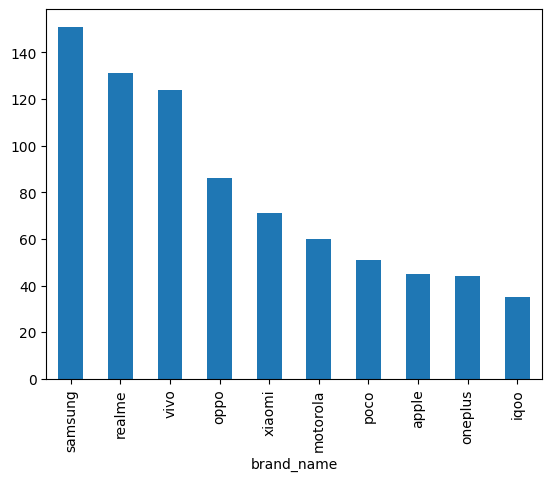

In [93]:
# categorical analysis of brand_name
df1['brand_name'].value_counts().head(10).plot(kind='bar')

<Axes: ylabel='count'>

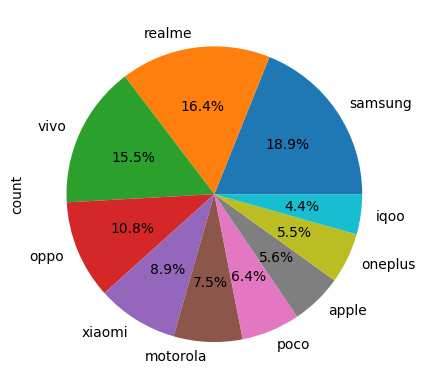

In [94]:
# categorical analysis of brand_name
df1['brand_name'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')

In [95]:
df1['brand_name'].isna().sum()

np.int64(0)

In [96]:
# price columan analysis
df1['mobile_price'].describe()

count       960.000000
mean      30772.726042
std       32013.566021
min        3999.000000
25%       13373.750000
50%       20499.000000
75%       32171.750000
max      229900.000000
Name: mobile_price, dtype: float64

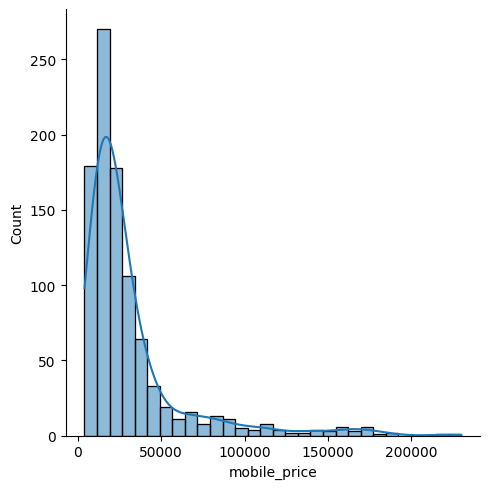

In [97]:
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

# displot
sns.displot(df1['mobile_price'], bins=30, kde=True)
# left skewed distribution

In [98]:
df1['mobile_price'].skew()

np.float64(2.8908520605678)

<Axes: xlabel='mobile_price'>

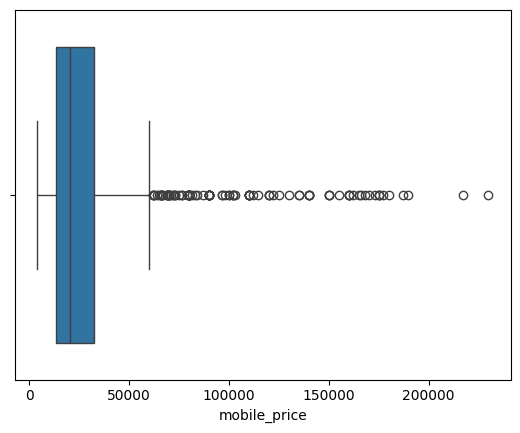

In [99]:
# boxplot for mobile price
sns.boxplot(x=df1['mobile_price'])

In [100]:
# study the outlier phone if nessasary we need to drop or impute them based on the analysis
df1[df1['mobile_price'] > 150000] # in the real word these phones brands are making difference in the price  these brands column make a influence on this price hence these are valid entries hence we dont need to drop them

,brand_name,mobile_name,mobile_price,mobile_rank,has_5g,has_nfc,has_ir,processor_brand,processor_cores,processor_speed,ram_size,rom_size,battery_capacity,charger_wattage,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,os_category
165,samsung,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),216999,97.0,True,True,False,snapdragon,8,4.47,16,1024,4400,25,8.00,1968,2184,120,3,2,200.0,10.0,True,Android
249,samsung,Samsung Galaxy Z Fold 7,174999,95.0,True,True,False,snapdragon,8,4.47,12,256,4400,25,8.00,1968,2184,120,3,2,200.0,10.0,True,Android
253,apple,Apple iPhone 17 Pro Max (1TB),189900,83.0,True,True,False,apple,6,NaN,12,1024,4832,<NA>,6.90,1320,2868,120,3,1,48.0,18.0,False,iOS
308,samsung,Samsung Galaxy S25 Ultra (12GB RAM + 1TB),165999,94.0,True,True,False,snapdragon,8,4.47,12,1024,5000,45,6.90,1440,3120,120,4,1,200.0,12.0,False,Android
320,apple,Apple iPhone 17 Pro Max (2TB),229900,84.0,True,True,False,apple,6,NaN,12,2048,4832,<NA>,6.90,1320,2868,120,3,1,48.0,18.0,False,iOS
395,samsung,Samsung Galaxy S24 Ultra (12GB RAM + 1TB),159999,94.0,True,True,False,snapdragon,8,3.30,12,1024,5000,45,6.80,1440,3120,120,4,1,200.0,12.0,False,Android
396,vivo,Vivo X Fold 3 Pro,159999,96.0,True,True,True,snapdragon,8,3.30,16,512,5700,100,8.03,2200,2480,120,3,2,64.0,32.0,False,Other
440,apple,Apple iPhone 17 Pro Max (512GB),169900,83.0,True,True,False,apple,6,NaN,12,512,4832,<NA>,6.90,1320,2868,120,3,1,48.0,18.0,False,iOS
503,apple,Apple iPhone 15 Pro Max (512GB),179900,87.0,True,True,False,bionic,6,3.78,8,512,4441,<NA>,6.70,1290,2796,120,3,1,48.0,12.0,False,iOS
544,samsung,Samsung Galaxy S23 Ultra (12GB RAM + 512GB),161999,92.0,True,True,False,snapdragon,8,3.36,12,512,5000,45,6.80,1440,3088,120,4,1,200.0,12.0,False,Android


In [101]:
df1['mobile_price'].isna().sum()

np.int64(0)

In [102]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 0 to 963
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   brand_name                 960 non-null    object  
 1   mobile_name                960 non-null    object  
 2   mobile_price               960 non-null    int64   
 3   mobile_rank                570 non-null    float64 
 4   has_5g                     960 non-null    bool    
 5   has_nfc                    960 non-null    bool    
 6   has_ir                     960 non-null    bool    
 7   processor_brand            959 non-null    object  
 8   processor_cores            953 non-null    Int64   
 9   processor_speed            922 non-null    float64 
 10  ram_size                   957 non-null    Int64   
 11  rom_size                   959 non-null    Int64   
 12  battery_capacity           956 non-null    Int64   
 13  charger_wattage            884 non-null 

In [103]:
# move to mobile rank column analysis
df1['mobile_rank'].describe()

count    570.000000
mean      84.277193
std        3.449409
min       80.000000
25%       82.000000
50%       84.000000
75%       86.000000
max       97.000000
Name: mobile_rank, dtype: float64

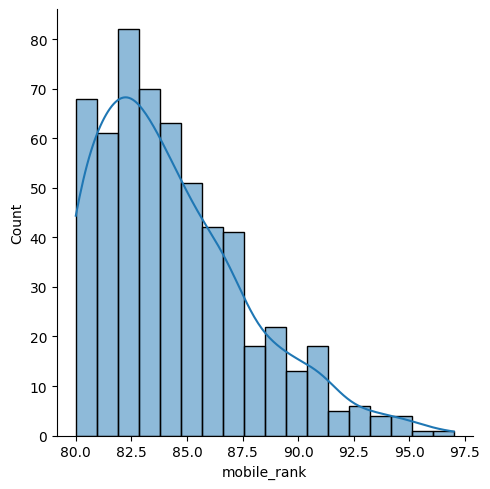

In [104]:
sns.displot(df1['mobile_rank'], kde=True) # right skewed distribution

In [105]:
df1['mobile_rank'].skew()

np.float64(0.9537042466301444)

<Axes: xlabel='mobile_rank'>

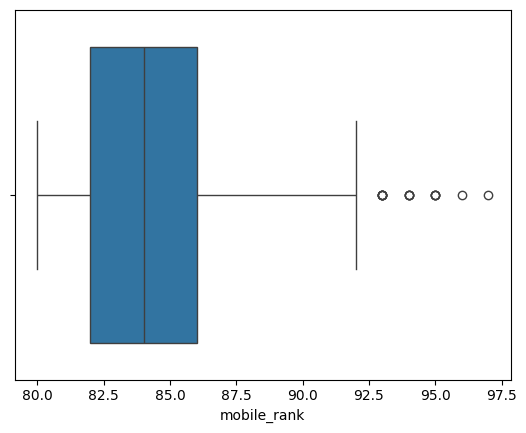

In [106]:
#Boxplot for mobile rank
sns.boxplot(x=df1['mobile_rank'])

In [107]:
df1['mobile_rank'].isna().sum()/960
# this is 40% missing values which is high it is hard to impute by any statistical method hence
#  we can use machine learning model (KNN imputer) to predict the missing values based on other feature columns


np.float64(0.40625)

In [108]:
df1.corr(numeric_only=True)['mobile_rank']
# mobile ranting as correclation with many columns we can use these info to predict the missing values using KNN imputer

mobile_price                 0.622994
mobile_rank                  1.000000
has_5g                       0.124526
has_nfc                      0.508974
has_ir                       0.108220
processor_cores              0.031099
processor_speed              0.622920
ram_size                     0.606117
rom_size                     0.526860
battery_capacity            -0.092581
charger_wattage              0.133752
screen_size                  0.345762
display_resolution_width     0.556042
display_resolution_height    0.411180
display_refresh_rate         0.135625
num_rear_cameras             0.303121
num_front_cameras            0.359895
primary_rear_camera          0.283398
primary_front_camera         0.159209
memory_card_support         -0.260232
Name: mobile_rank, dtype: float64

In [109]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 0 to 963
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   brand_name                 960 non-null    object  
 1   mobile_name                960 non-null    object  
 2   mobile_price               960 non-null    int64   
 3   mobile_rank                570 non-null    float64 
 4   has_5g                     960 non-null    bool    
 5   has_nfc                    960 non-null    bool    
 6   has_ir                     960 non-null    bool    
 7   processor_brand            959 non-null    object  
 8   processor_cores            953 non-null    Int64   
 9   processor_speed            922 non-null    float64 
 10  ram_size                   957 non-null    Int64   
 11  rom_size                   959 non-null    Int64   
 12  battery_capacity           956 non-null    Int64   
 13  charger_wattage            884 non-null 

In [110]:
df1['processor_brand'].value_counts()

processor_brand
dimensity     396
snapdragon    342
exynos         62
helio          53
unisoc         35
bionic         32
tensor         17
apple          12
google          4
tiger           3
a13             1
dimensit        1
sc9863a         1
Name: count, dtype: int64

In [111]:
# before this i will convert the categorical columns to numerical using one hot encoding for KNN imputer and binary encoding for boolean columns 
"""
 here i think we have some influce of rank based on the os_category hence we can one hot encode 
 this column and also we will drop mobile price column for prediction and bcz this is our target column in future 
 and we also needs to drop all other object type columns
 """
df1 = pd.get_dummies(df1, columns=['os_category'], drop_first=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 0 to 963
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 960 non-null    object 
 1   mobile_name                960 non-null    object 
 2   mobile_price               960 non-null    int64  
 3   mobile_rank                570 non-null    float64
 4   has_5g                     960 non-null    bool   
 5   has_nfc                    960 non-null    bool   
 6   has_ir                     960 non-null    bool   
 7   processor_brand            959 non-null    object 
 8   processor_cores            953 non-null    Int64  
 9   processor_speed            922 non-null    float64
 10  ram_size                   957 non-null    Int64  
 11  rom_size                   959 non-null    Int64  
 12  battery_capacity           956 non-null    Int64  
 13  charger_wattage            884 non-null    Int64  
 14 

In [112]:
df2 = df1.drop(columns=['brand_name', 'mobile_name', 'mobile_price', 'processor_brand'])

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
values = df2_imputed = imputer.fit_transform(df2)

df2 = pd.DataFrame(values, columns=df2.columns)

In [113]:
# we campare the correlation of mobile_price column before and after imputation to check the changes
df2['mobile_price'] = df1['mobile_price']

a = df2.corr()['mobile_price'].reset_index()
b = df1.corr(numeric_only=True)['mobile_price'].reset_index()

pd.merge(a, b, on='index', suffixes=('_after_imputation', '_before_imputation'))

,index,mobile_price_after_imputation,mobile_price_before_imputation
0,mobile_rank,0.405221,0.622994
1,has_5g,0.056686,0.241751
2,has_nfc,0.276916,0.493673
3,has_ir,0.023135,-0.050886
4,processor_cores,-0.104224,-0.248780
5,processor_speed,0.396406,0.732459
6,ram_size,0.291427,0.528671
7,rom_size,0.359780,0.712328
8,battery_capacity,-0.082052,-0.220778
9,charger_wattage,0.100607,0.229535


<Axes: ylabel='count'>

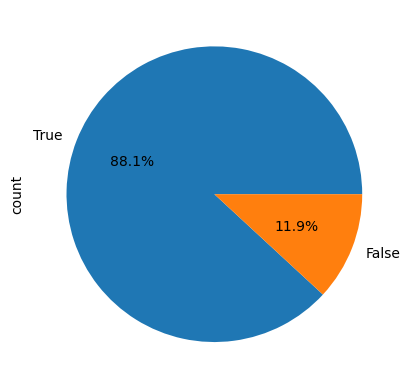

In [114]:
df1['has_5g'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: ylabel='count'>

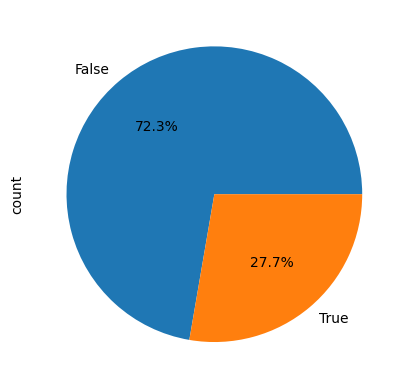

In [115]:
df1['has_ir'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: ylabel='count'>

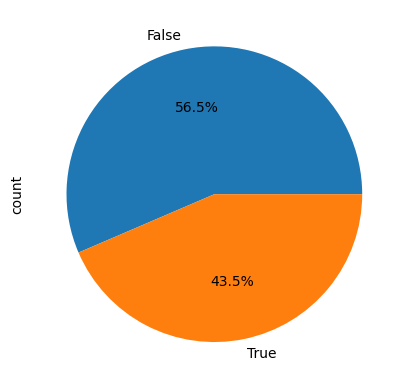

In [116]:
df1['has_nfc'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='processor_brand'>

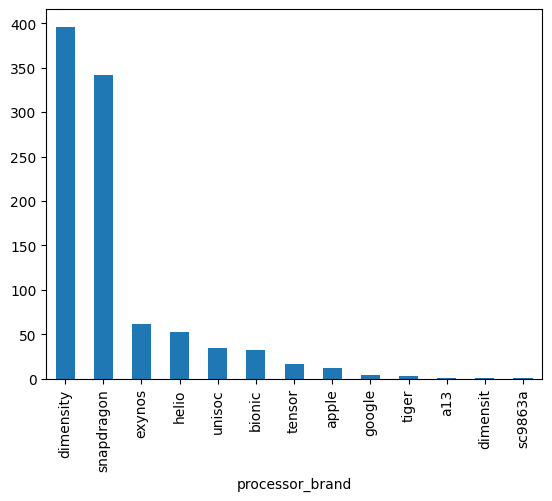

In [117]:
df1['processor_brand'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

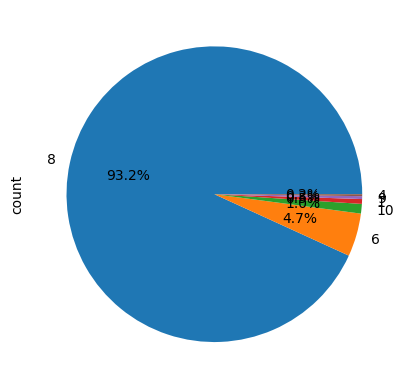

In [118]:
df1['processor_cores'].value_counts().plot(kind='pie', autopct='%1.1f%%') # imbalence data not much effect on model

<Axes: xlabel='ram_size'>

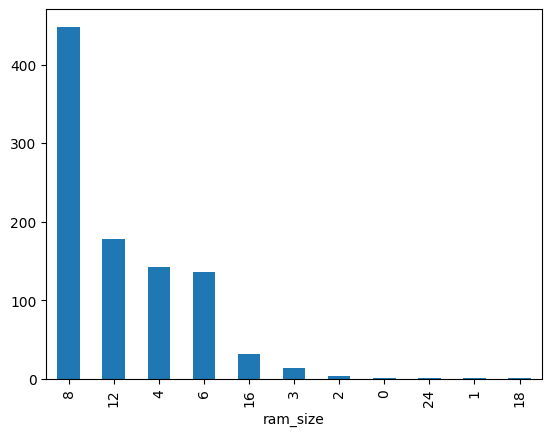

In [119]:
df1['ram_size'].value_counts().plot(kind='bar')

<Axes: xlabel='rom_size'>

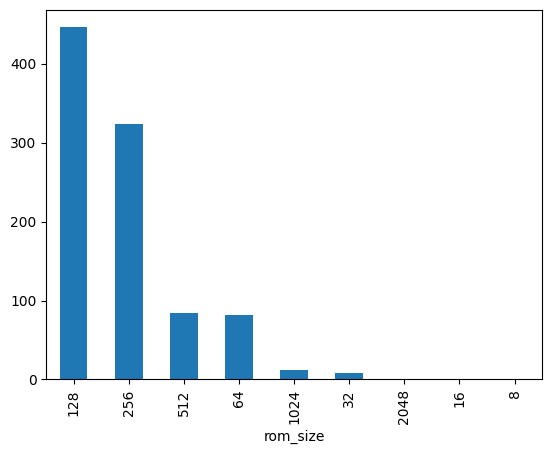

In [120]:
df1['rom_size'].value_counts().plot(kind='bar')

<Axes: xlabel='charger_wattage'>

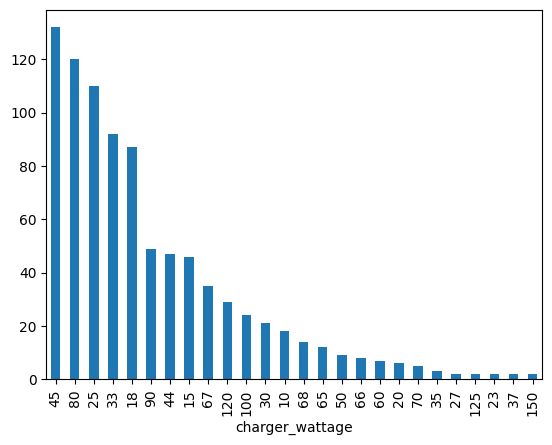

In [121]:
df1['charger_wattage'].value_counts().plot(kind='bar')

<Axes: xlabel='display_refresh_rate'>

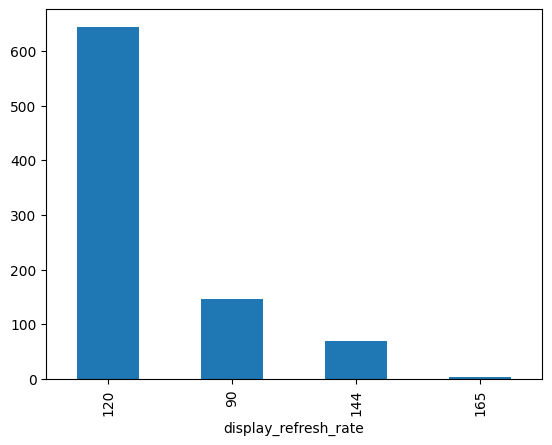

In [122]:
df1['display_refresh_rate'].value_counts().plot(kind='bar')

<Axes: xlabel='num_front_cameras'>

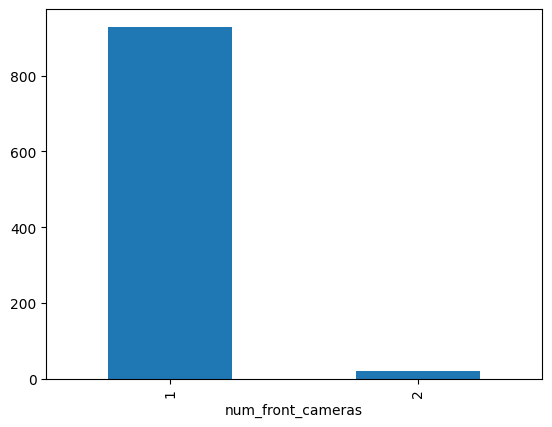

In [123]:
df1['num_front_cameras'].value_counts().plot(kind='bar')

<Axes: xlabel='num_rear_cameras'>

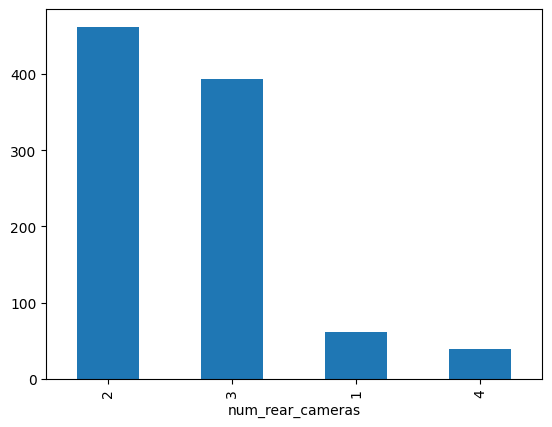

In [124]:
df1['num_rear_cameras'].value_counts().plot(kind='bar')

In [125]:
df1.head(1)

,brand_name,mobile_name,mobile_price,mobile_rank,has_5g,has_nfc,has_ir,processor_brand,processor_cores,processor_speed,ram_size,rom_size,battery_capacity,charger_wattage,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,os_category_Other,os_category_iOS
0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,True,True,False,snapdragon,8,3.3,12,256,5000,45,6.8,1440,3120,120,4,1,200.0,12.0,False,False,False


In [126]:
numerical_cols = df1.iloc[:, [9, 12, 13,14,15,20,21]]
numerical_cols

,processor_speed,battery_capacity,charger_wattage,screen_size,display_resolution_width,primary_rear_camera,primary_front_camera
0,3.30,5000,45,6.80,1440,200.0,12.0
1,3.35,7100,80,6.77,1080,50.0,16.0
2,3.46,3349,<NA>,6.10,1179,48.0,12.0
3,2.50,6500,90,6.77,1080,200.0,50.0
4,3.35,6000,80,6.83,1272,50.0,16.0
...,...,...,...,...,...,...,...
959,2.00,6000,15,6.50,720,48.0,8.0
960,2.84,4500,65,6.55,1080,48.0,16.0
961,2.40,4000,33,6.44,1080,64.0,44.0
962,2.00,6000,18,6.50,720,48.0,8.0


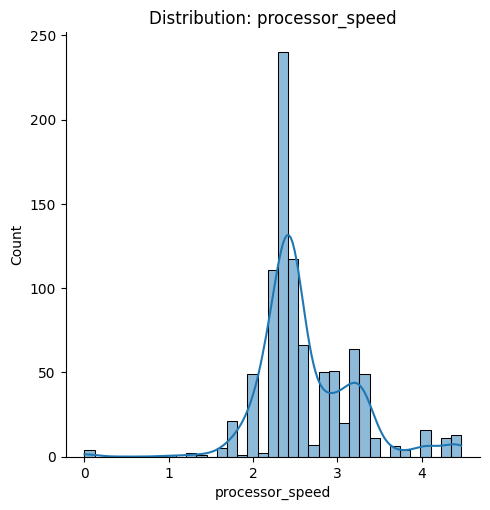

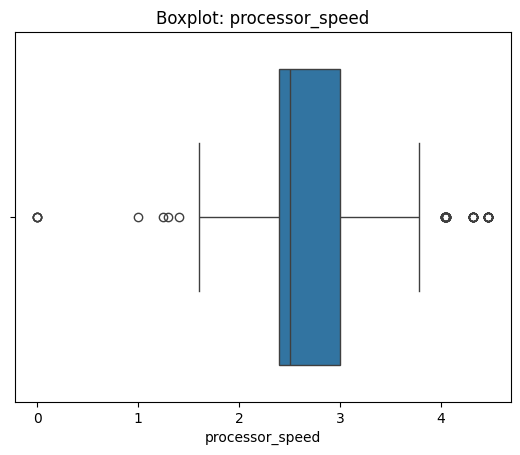

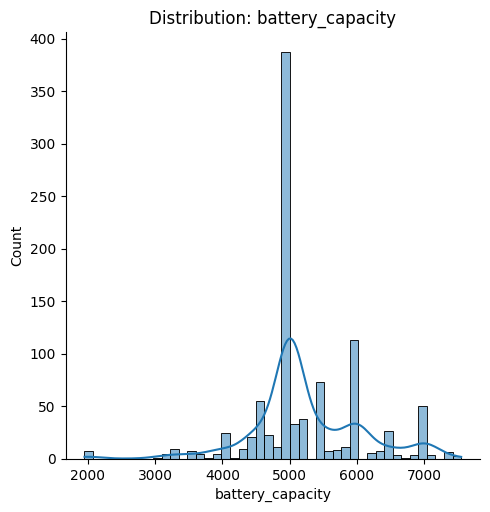

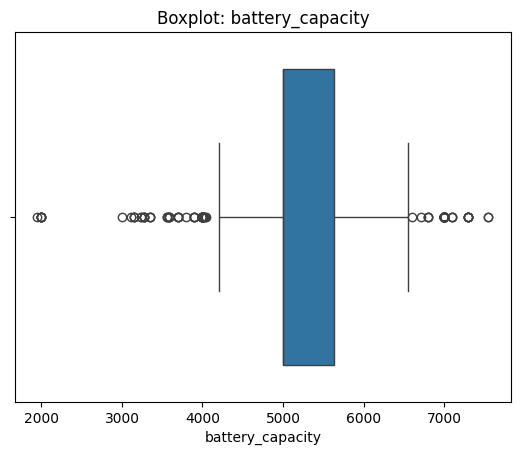

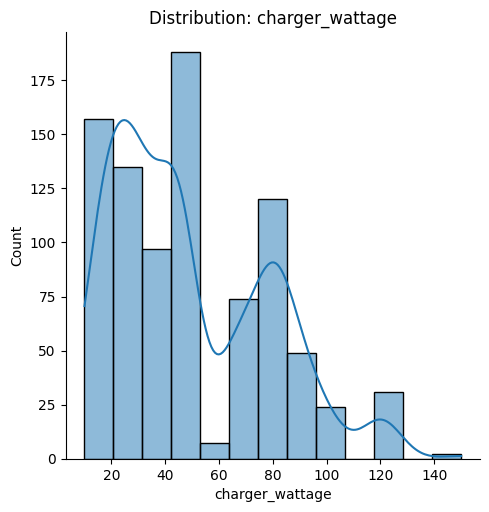

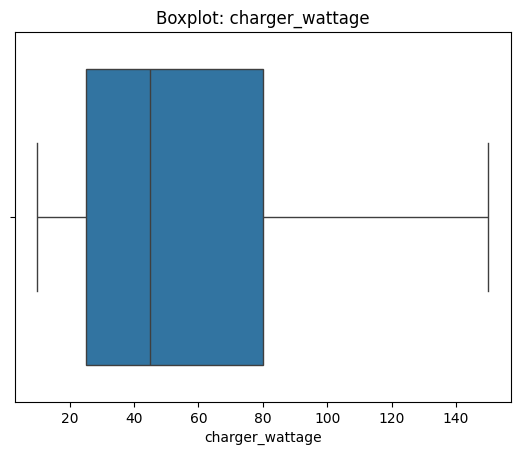

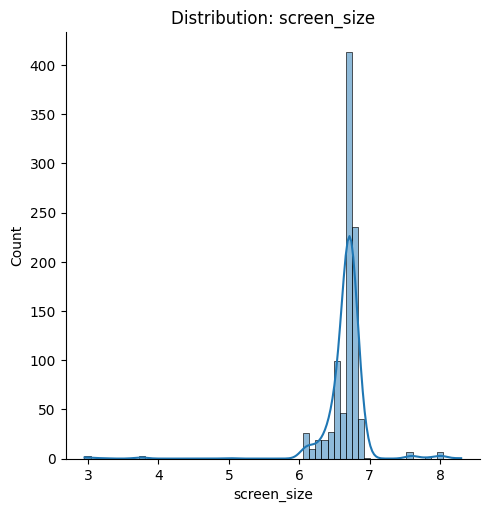

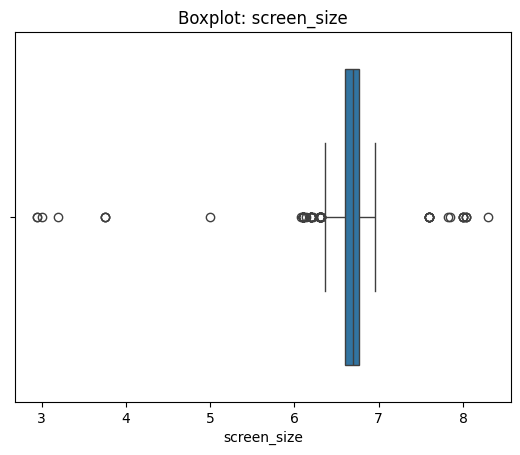

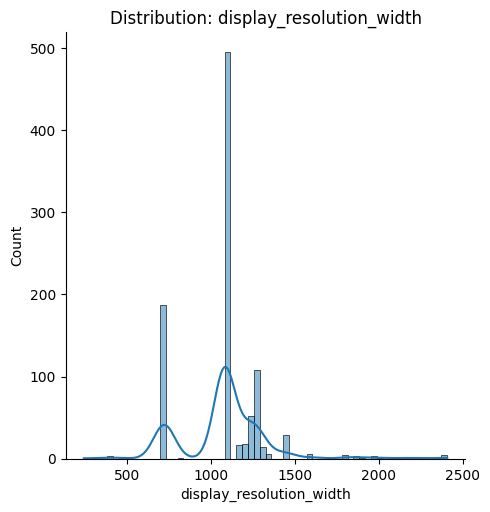

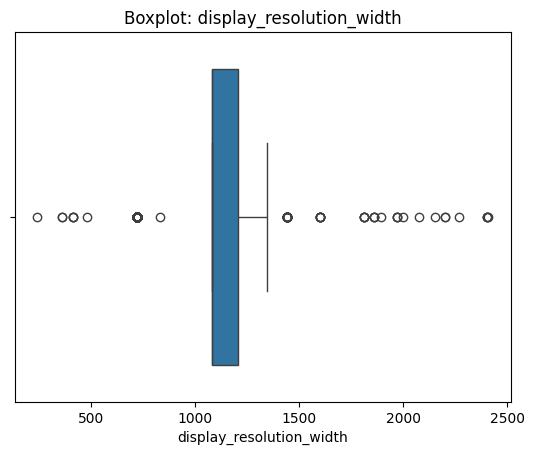

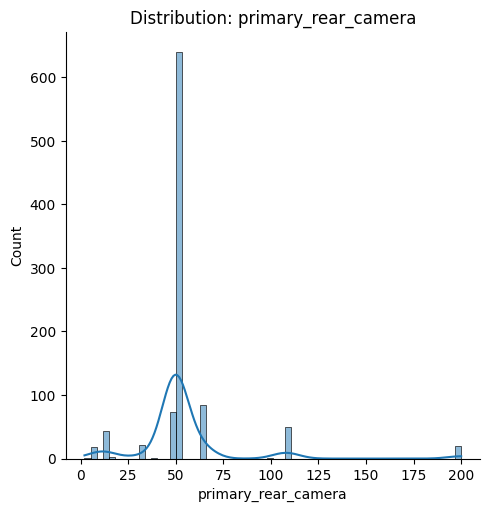

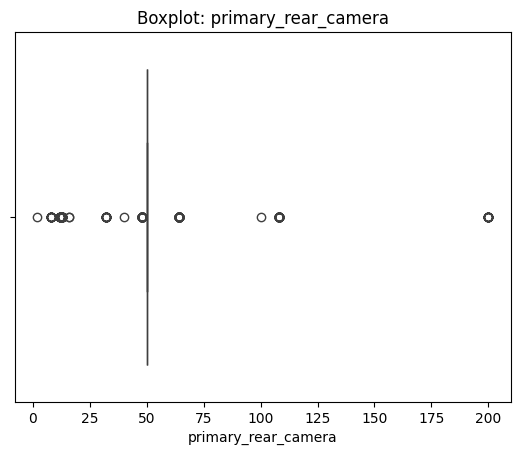

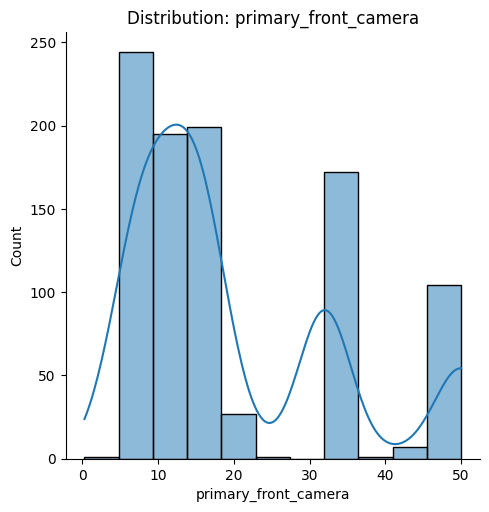

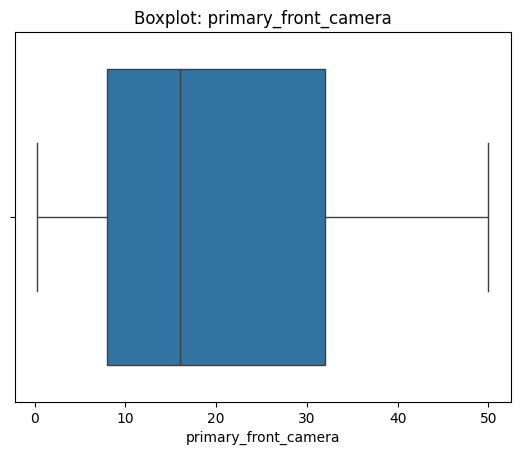

In [127]:
# Plot selected numerical columns (use column positions on df1.columns to avoid out-of-bounds iloc)
# we pick the same positional columns used earlier: [9,12,13,14,15,20,21]
# map them to names first so selection is robust to dtype-based subsetting
selected_idxs = [9, 12, 13, 14, 15, 20, 21]
numerical_cols = df1.columns[selected_idxs].tolist()

for column_name in numerical_cols:
    # skip non-numeric columns (safe-guard)
    if not pd.api.types.is_numeric_dtype(df1[column_name]):
        print(f"Skipping non-numeric column: {column_name}")
        continue

    # dropna to avoid plotting issues when column is entirely NaN
    series = df1[column_name].dropna()

    if series.empty:
        print(f"No data to plot for column: {column_name}")
        continue

    sns.displot(series, kde=True)
    plt.title(f"Distribution: {column_name}")
    plt.show()

    sns.boxplot(x=series)
    plt.title(f"Boxplot: {column_name}")
    plt.show()

#### **biverient analysis** 


<Axes: xlabel='brand_name', ylabel='mobile_price'>

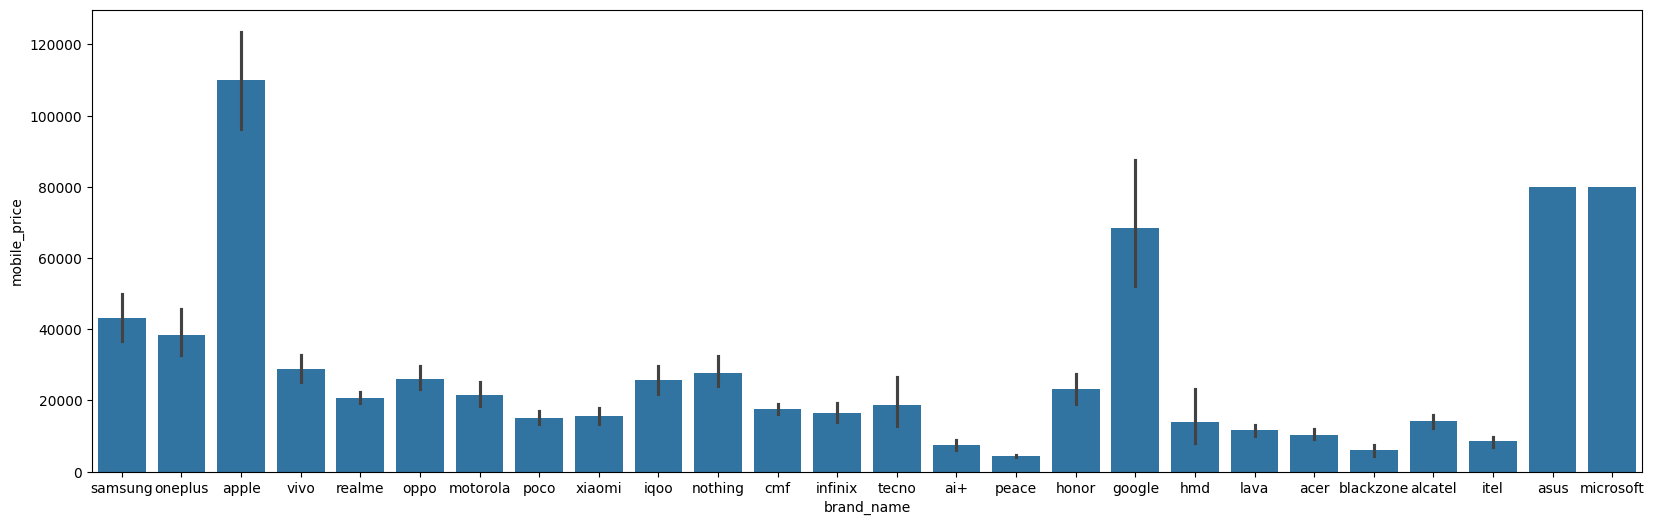

In [128]:
# price analysis with brand_name using barplot
plt.figure(figsize=(20, 6))
sns.barplot(x='brand_name', y='mobile_price', data=df1)

# shows that brand name has influence on the price of the mobile phone

"not having strong correlation between price and rank \nbeacuse rank of the mobile phone may be givien by the price range \nwith in the different range of price we have good and poor ranking as well that's why\nthe only price is not infulencing the rank and visa versa \n"

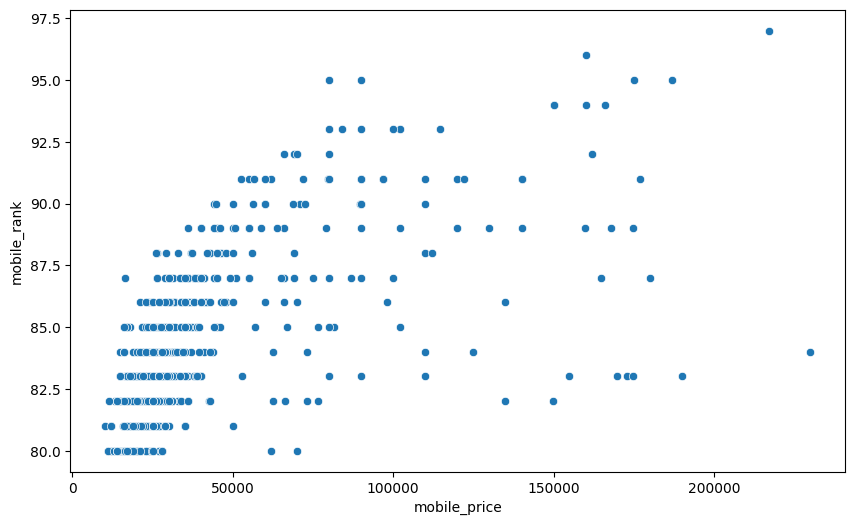

In [129]:
# scaltter plot for price vs rank
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mobile_price', y='mobile_rank', data=df1)
"""not having strong correlation between price and rank 
beacuse rank of the mobile phone may be givien by the price range 
with in the different range of price we have good and poor ranking as well that's why
the only price is not infulencing the rank and visa versa 
""" 

<Axes: xlabel='has_5g', ylabel='mobile_price'>

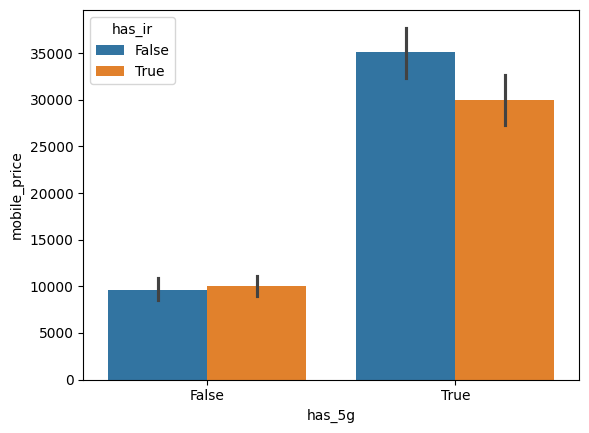

In [130]:
# campare 5g and price
sns.barplot(x='has_5g', y='mobile_price', data=df1, hue='has_ir')
# shows that 5G phones are generally priced higher than non-5G phones but with ir blaster the is no much effect on price 

<Axes: xlabel='has_5g', ylabel='mobile_price'>

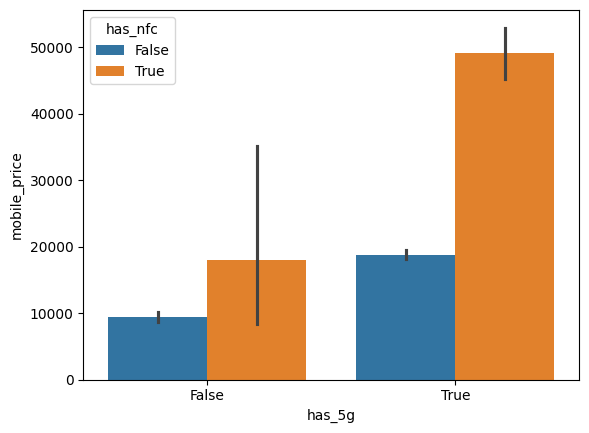

In [131]:

sns.barplot(x='has_5g', y='mobile_price', data=df1, hue='has_nfc')
# both 5g and nfc has influence on the price of the mobile phone

<Axes: xlabel='processor_brand', ylabel='mobile_price'>

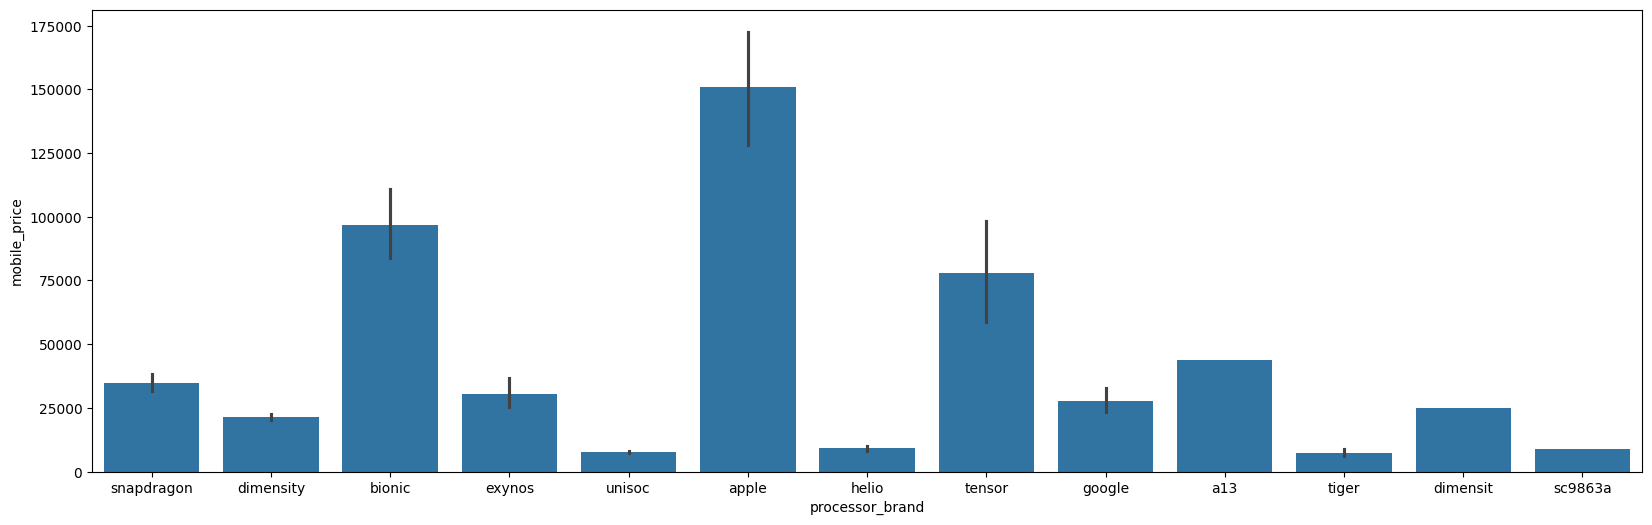

In [132]:
# campare price with processor brand
plt.figure(figsize=(20, 6))
sns.barplot(x='processor_brand', y='mobile_price', data=df1)
# shows that processor brand has influence on the price of the mobile phone

<Axes: xlabel='processor_cores', ylabel='mobile_price'>

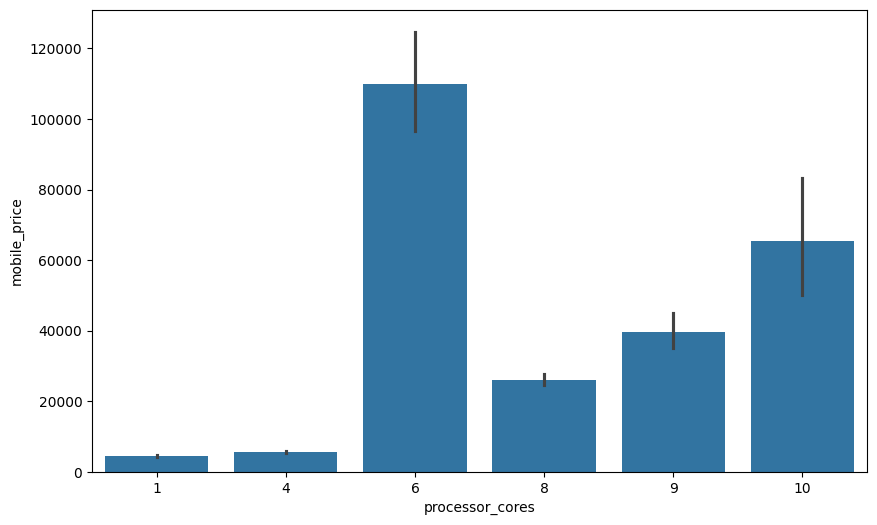

In [133]:
# campare price with processor cores
plt.figure(figsize=(10, 6))
sns.barplot(x='processor_cores', y='mobile_price', data=df1)
# shows that processor cores has influence on the price of the mobile phone

<Axes: xlabel='processor_speed', ylabel='mobile_price'>

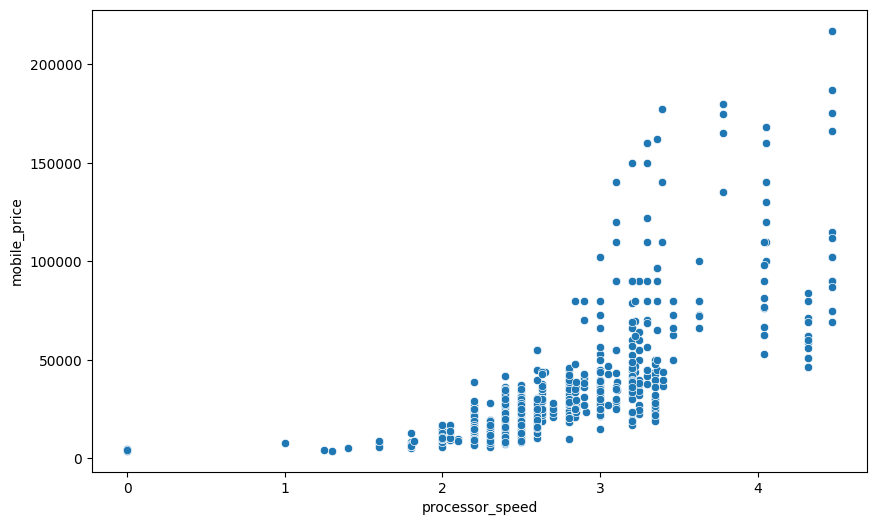

In [134]:
# campare processor speed with price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='processor_speed', y='mobile_price', data=df1)
# shows that processor speed has influence on the price of the mobile phone

<Axes: xlabel='screen_size', ylabel='mobile_price'>

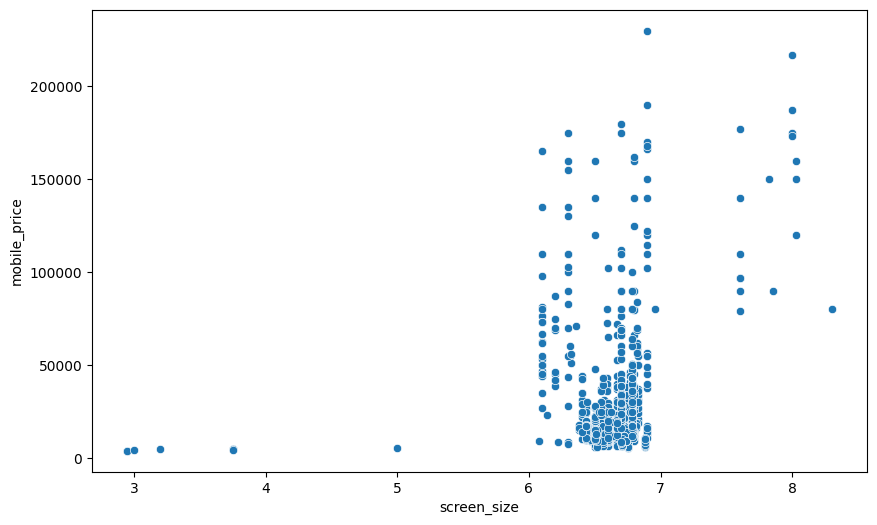

In [135]:
# campare price with scrreen size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='screen_size', y='mobile_price', data=df1)
# shows that screen size has not much influence on the price of the mobile phone

<Axes: >

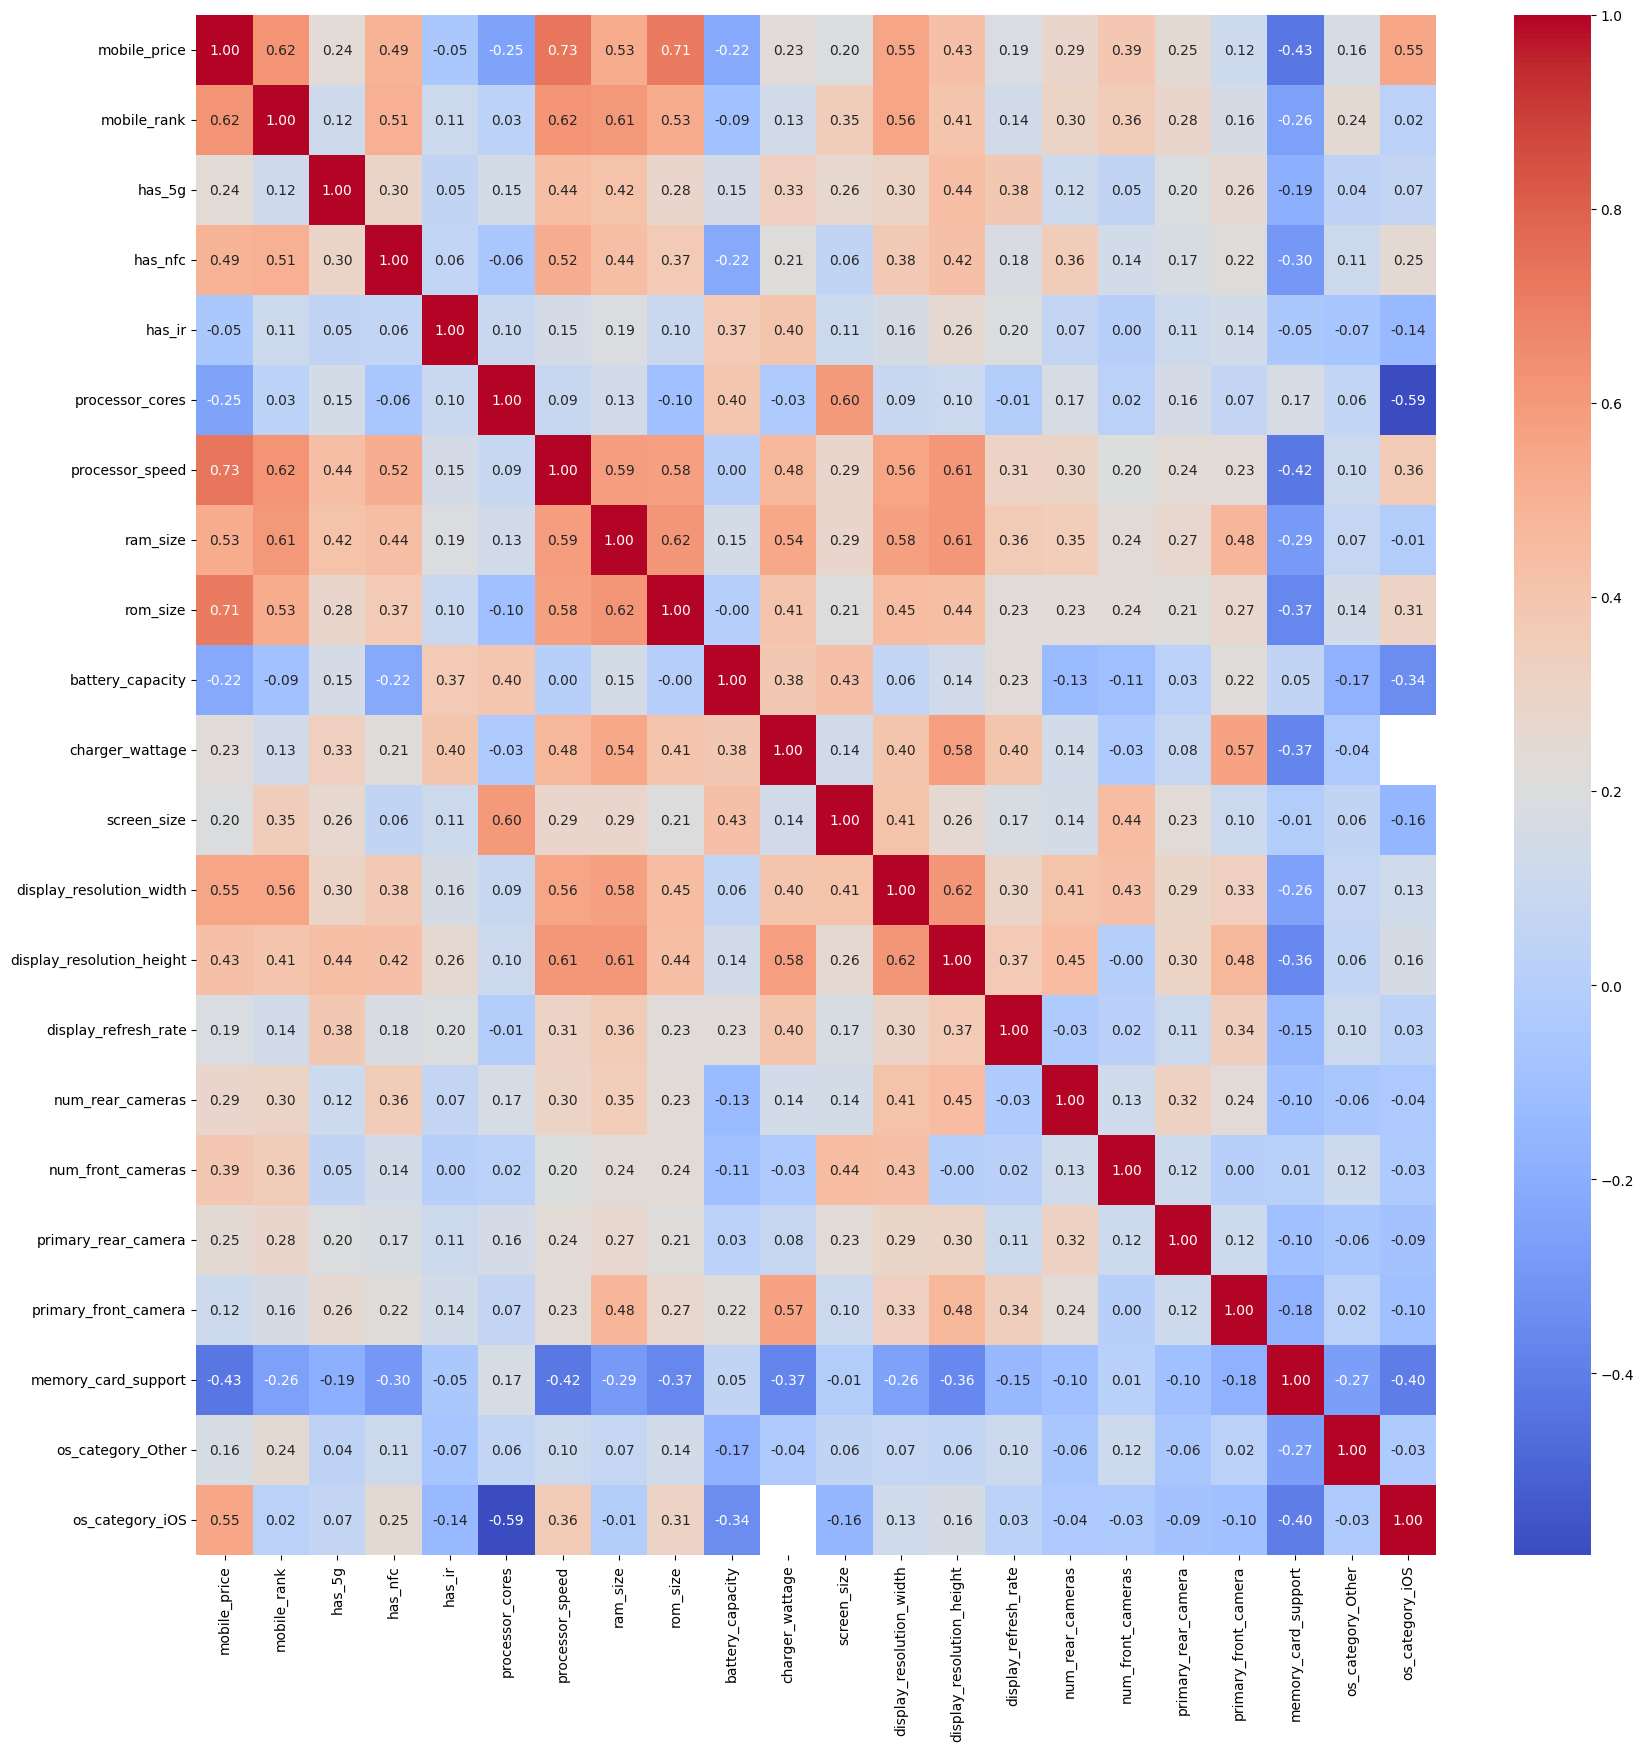

In [136]:
# compute correlation on numeric columns to avoid conversion errors
plt.figure(figsize=(20, 20))
sns.heatmap(df1.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')